In [49]:
#!pip install matplotlib

In [1]:
import numpy as np
import time
import torch
import time
import sys
import scipy
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

Random network shape: (50, 50)
Small-world network shape: (50, 50)


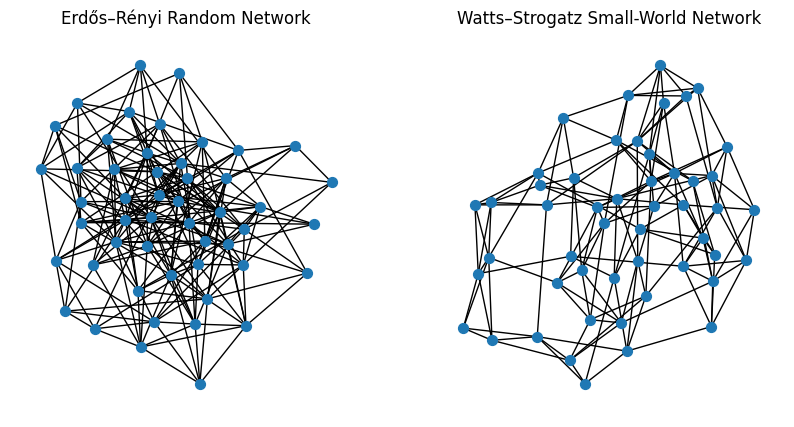

In [32]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 50              # number of nodes
p_random = 0.2      # connection probability for random net
k_neighbors = 6     # number of nearest neighbors for WS model
p_rewire = 0.3      # rewiring probability for WS model

#Fully random network (Erdős–Rényi model) ---
G_random = nx.erdos_renyi_graph(N, p_random)

# Small-world network (Watts–Strogatz model) ---
G_ws = nx.watts_strogatz_graph(N, k_neighbors, p_rewire)

# --- Convert to adjacency matrices (numpy arrays) ---
A_random = nx.to_numpy_array(G_random)
A_ws = nx.to_numpy_array(G_ws)

print("Random network shape:", A_random.shape)
print("Small-world network shape:", A_ws.shape)

# --- Optional: visualize ---
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
nx.draw(G_random, node_size=50, ax=ax[0], with_labels=False)
ax[0].set_title("Erdős–Rényi Random Network")
nx.draw(G_ws, node_size=50, ax=ax[1], with_labels=False)
ax[1].set_title("Watts–Strogatz Small-World Network")
plt.show()


In [2]:
# Generate Networks

In [2]:
import numpy as np
import networkx as nx
from scipy.stats import nbinom
import matplotlib.pyplot as plt
import secrets
# ---------------- Utilidades para generar grafos ----------------
def generate_degrees(n, mean_k, var_k):
    """Genera una secuencia de grados con media y varianza aproximadas.
    This function's primary role is to create a sequence of degrees for a graph with $n$ nodes,
    ensuring the sequence adheres to a desired average degree ($\text{mean\_k}$) and
    degree variability ($\text{var\_k}$).
    It achieves this by sampling from a Negative Binomial distribution
    (a common choice for modeling real-world networks) and then performs necessary clean-up steps:
    it clips the degrees to be positive and less than $n$, and it adjusts one degree
    by $\pm 1$ if the total sum of degrees is odd, which is a mathematical requirement
    for a simple graph to exist.
    """


    if var_k <= mean_k:
        raise ValueError("La varianza debe ser mayor que la media para la Negativa Binomial.")
    p = mean_k / var_k
    r = mean_k * p / (1 - p)
    degs = nbinom(r, p).rvs(size=n)
    degs = np.clip(degs, 1, n-1)
    if np.sum(degs) % 2 == 1:
        idx = np.random.randint(0, n)
        degs[idx] += 1 if degs[idx] < n-1 else -1
    return degs

def ensure_connected(G):
    """Ensure the graph is connected by linking components if necessary.
    This function guarantees that the input graph $G$ is a single, unified component.
    It first checks if the graph is already connected. If it is not, it iterates through all
    separate connected components, randomly selecting one node from each pair of adjacent
    components and adding a single edge between them until the entire graph is connected.
    This ensures that the final graph structure is ready for analysis or simulation that
    requires connectivity.


    """
    if nx.is_connected(G):
        return G

    components = list(nx.connected_components(G))
    # Connect components sequentially with random nodes from each
    for i in range(len(components) - 1):
        u = np.random.choice(list(components[i]))
        v = np.random.choice(list(components[i + 1]))
        G.add_edge(u, v)

    assert nx.is_connected(G)
    return G

def generate_connected_graph(n=500, mean_k=6, var_k=20, seed=None):
    """Genera un grafo conexo con la secuencia de grados objetivo.
    This is the main execution function that generates a complete, connected graph with
    specific size and degree properties. It first sets the random seed for reproducibility.
    It then calls generate_degrees to create the target degree sequence and uses
    a network construction algorithm like $\text{Havel-Hakimi}$ or
    $\text{Configuration Model}$ (from $\text{NetworkX}$) to build the graph based on those degrees.
    Finally, it calls ensure_connected
    to guarantee the resulting graph is usable, returning the final, fully-constructed graph $G$.
    """
    np.random.seed(seed)
    degrees = generate_degrees(n, mean_k, var_k)
    try:
        G = nx.havel_hakimi_graph(degrees)
    except nx.NetworkXError:
        G = nx.configuration_model(degrees)
        G = nx.Graph(G)
        G.remove_edges_from(nx.selfloop_edges(G))
    G = ensure_connected(G)
    return G

def generate_secure_seed():
    """
    Generates a cryptographically secure, 32-bit integer.
    This range (0 to 2**32 - 1) is fully compatible with np.random.seed().
    """
    return secrets.randbits(32)

<>:10: SyntaxWarning: invalid escape sequence '\_'
<>:10: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_2086/5310333.py:10: SyntaxWarning: invalid escape sequence '\_'
  ensuring the sequence adheres to a desired average degree ($\text{mean\_k}$) and


## Kuramoto Model

In [3]:
import torch
import numpy as np
from typing import List
import tqdm

Complex = torch.complex128

class KuramotoFast:
    def __init__(self, n_nodes: int, n_oscillators: int, sampling_rate: int, k_list: List[float], weight_matrix: np.ndarray,
                 frequency_spread: float, noise_scale: float=1.0, use_cuda: bool=True, use_tqdm: bool=True, node_frequencies=None, **kwargs):
        """
            Implementation of nested Kuramoto model using PyTorch. The model consists of N nodes each with M oscillators. Each pair of nodes is connected with directed weight given by weight_matrix.

            :param n_nodes: number of nodes in the model
            :param n_oscillators: number of oscillators in each node
            :param sampling_rate: update rate of the model
            :param k_list: list of K values (within node shift) of the model. Should have length equal to number of nodes.
            :param weight_matrix: 2d matrix of node vs node connectivity weight. Should have N_nodes x N_nodes shape.
            :param frequency_spread: spread of frequencies within a node. Frequencies of oscillators are defined as linspace from central_frequency - frequency_spread to central_frequency + frequency_spread
            :param noise_scale: sigma of noise.
            :param use_cuda: use GPU (PyTorch CUDA/ROCm) to compute the model?
        """
        self._check_parameters(n_nodes, k_list, weight_matrix)

        # Set device
        if use_cuda and torch.cuda.is_available():
            self.device = torch.device("cuda")
            device_name = "GPU (CUDA/ROCm)"
        else:
            self.device = torch.device("cpu")
            device_name = "CPU"
        print(f"Using device: {device_name}")

        self.n_nodes = n_nodes
        self.n_oscillators = n_oscillators
        self.k_list = k_list
        self.noise_scale = 2 * np.pi * noise_scale / sampling_rate

        self.frequency_spread = frequency_spread
        self.node_frequencies = node_frequencies

        # Convert weight_matrix to PyTorch tensor
        self.weight_matrix = torch.tensor(weight_matrix, dtype=torch.float64, device=self.device)
        torch.diagonal(self.weight_matrix).fill_(0)  # Set diagonal to 0
        self.weight_matrix = self.weight_matrix.T  # Transpose for directed connectivity

        self.sampling_rate = sampling_rate
        self.dt = 1.0 / sampling_rate
        self.use_cuda = use_cuda
        self.disable_tqdm = not(use_tqdm)

        self._init_parameters()
        self._preallocate()

    def _check_parameters(self, n_nodes: int, k_list: List[float], weight_matrix: np.ndarray):
        if len(k_list) != n_nodes:
            raise RuntimeError(f'Size of k_list ({len(k_list)}) is not equal to number of nodes ({n_nodes}).')
        if np.ndim(weight_matrix) != 2 or (weight_matrix.shape[0] != weight_matrix.shape[1]):
            raise RuntimeError(f'weight_matrix should be a 2d square matrix, got {weight_matrix.shape} shape.')
        if weight_matrix.shape[0] != n_nodes or weight_matrix.shape[1] != n_nodes:
            raise RuntimeError(f'weight matrix should be a 2d matrix of size N_nodes x N_nodes, got {weight_matrix.shape} shape')

    def _init_parameters(self):
        # Angular frequencies in rad/s
        omegas = torch.zeros((self.n_nodes, self.n_oscillators), dtype=torch.float64, device=self.device)
        for idx, frequency in enumerate(self.node_frequencies):
            freq_lower = frequency - self.frequency_spread
            freq_upper = frequency + self.frequency_spread
            omegas[idx] = torch.linspace(freq_lower, freq_upper, steps=self.n_oscillators, device=self.device, dtype=torch.float64)

        omegas += torch.rand(omegas.shape, device=self.device, dtype=torch.float64) * 0.2 - 0.1  # Uniform [-0.1, 0.1]
        self.omegas = omegas * 2 * np.pi  # rad/s

        # Shift coeffs
        C = torch.tensor(self.k_list, dtype=torch.float64, device=self.device) / self.n_oscillators
        self.shift_coeffs = C.view(-1, 1)

        # Random initial phase
        thetas = torch.rand(omegas.shape, device=self.device, dtype=torch.float64) * 2 * np.pi - np.pi  # Uniform [-π, π]
        self.phases = torch.exp(1j * thetas)

        self._complex_dtype = torch.complex64
        self._float_dtype = torch.float32

    def _preallocate(self):
        n_nodes, n_osc = self.phases.shape
        self._phase_conj = torch.empty_like(self.phases)
        self._external_buffer = torch.empty((n_nodes, n_nodes, n_osc), dtype=self.phases.dtype, device=self.device)

    def _compute_rhs(self, phases):
        mean_phase = torch.mean(phases, dim=1)  # Shape: (n_nodes,)
        self._phase_conj = torch.conj(phases)  # Shape: (n_nodes, n_oscillators)

        # External dynamics
        # tensordot computes outer product: (n_nodes, n_oscillators) × (n_nodes,) → (n_nodes, n_oscillators, n_nodes)
        # permute reorders to (n_nodes, n_nodes, n_oscillators)
        self._external_buffer = torch.tensordot(self._phase_conj, mean_phase, dims=0).permute(0, 2, 1)
        weight_expanded = self.weight_matrix[:, :, None].expand(-1, -1, self.n_oscillators)  # Shape: (n_nodes, n_nodes, n_oscillators)
        self._external_buffer *= weight_expanded
        external = self._external_buffer.sum(dim=1)  # Shape: (n_nodes, n_oscillators)
        external_rhs = external.imag / self.n_nodes

        # Internal dynamics
        self._phase_conj = phases * torch.sum(self._phase_conj, dim=1, keepdim=True)
        self._phase_conj = torch.conj(self._phase_conj)
        internal_rhs = self._phase_conj.imag * self.shift_coeffs

        rhs = self.omegas + internal_rhs + external_rhs
        return rhs

    def simulate(self, time: float, noise_realisations: int=100, random_seed: int=42) -> np.ndarray:
        """
            Implementation of nested Kuramoto model with RK4 integration using PyTorch.

            :param time: Length of the simulation in seconds. Total number of samples is computed as sampling_rate x time + 1 (initial state)
            :param noise_realisations: Number of noise realisations to generate (not used in this version)
            :return: N_nodes x N_ts matrix of complex values that contains each node activity during the simulation
        """
        torch.manual_seed(random_seed)
        n_iters = int(time * self.sampling_rate)
        history = torch.zeros((self.n_nodes, n_iters + 1), dtype=self._complex_dtype, device=self.device)
        history[:, 0] = self.phases.mean(dim=1)

        for i in tqdm.trange(1, n_iters + 1, leave=False, desc='Kuramoto model is running...', disable=self.disable_tqdm):
            # RK4 steps
            k1 = self._compute_rhs(self.phases)
            phases2 = self.phases * torch.exp(1j * (self.dt / 2) * k1)
            k2 = self._compute_rhs(phases2)
            phases3 = self.phases * torch.exp(1j * (self.dt / 2) * k2)
            k3 = self._compute_rhs(phases3)
            phases4 = self.phases * torch.exp(1j * self.dt * k3)
            k4 = self._compute_rhs(phases4)
            rhs = (k1 + 2 * k2 + 2 * k3 + k4) / 6

            shift_noise = torch.normal(mean=0.0, std=self.noise_scale, size=rhs.shape, device=self.device, dtype=torch.float64)
            rhs += shift_noise
            self.phases *= torch.exp(1j * self.dt * rhs)
            history[:, i] = self.phases.mean(dim=1)

        # Convert to NumPy for return
        history = history.cpu().numpy()
        return history

# Some other functions

In [4]:
from numpy.polynomial.polynomial import polyfit, polyval

def FA_metric(phasor, scales):
    """ y: cummulative sum, and scales should be defined"""
    y = calc_detrened(phasor)
    F_fa = np.zeros(len(scales))
    
    for i, s in enumerate(scales):

        diffs = y[s:] - y[:-s]
        F_fa[i] = np.sqrt(np.mean(diffs**2))

    # Fit log–log slope
    coeff_fa = np.polyfit(np.log2(scales), np.log2(F_fa), 1)
    alpha_fa = coeff_fa[0]
    fit_fa = 2 ** np.polyval(coeff_fa, np.log2(scales))

    # plt.figure(figsize=(7, 5))
    # plt.loglog(scales, F_fa, 'o', label="FA Data")
    # plt.loglog(scales, fit_fa, 'r--', label=f"Fit: α = {alpha_fa:.2f}")
    # plt.title("Fluctuation Analysis (FA)")
    # plt.xlabel("log₂(Window size s)")
    # plt.ylabel("log₂(Fluctuation F(s))")
    # plt.legend()
    # plt.grid(True, which="both", ls="--")
    # plt.show()

    print(f"Estimated FA exponent α = {alpha_fa:.3f}")

    return fit_fa, alpha_fa

def calc_detrened(data):
    x = np.abs(data)
    y = np.cumsum(x - np.mean(x))

    return y

def dfa_rms(y, scale):
    n_windows = len(y) // scale

    if n_windows == 0:
        return np.nan  # scale too large
        
    shape = (n_windows, scale)
    Y = np.lib.stride_tricks.as_strided(y, shape=shape)
    rms = np.zeros(n_windows)
    scale_axis = np.arange(scale)

    for i, window in enumerate(Y):
        coeff = np.polyfit(scale_axis, window, 1)
        trend = np.polyval(coeff, scale_axis)
        rms[i] = np.sqrt(np.mean((window - trend) ** 2))
    return np.mean(rms)


def dfa_scales(min_exp=5, max_exp=9, step=0.25):
    """
    Logarithmic scales: 2^5 ... 2^9 in reasonable increments.
    Ensures scales are strictly increasing and unique.
    """
    scales = np.round(2 ** np.arange(min_exp, max_exp, step)).astype(int)
    scales = np.unique(scales)
    return scales

def DFA(data):
    """
    Full DFA1 for a complex phasor time series.
    Returns (alpha, scales, F)
    """
    y = calc_detrened(data)
    scales = dfa_scales()

    F = []
    for s in scales:
        rms_val = dfa_rms(y, s)
        if not np.isnan(rms_val):
            F.append(rms_val)
        else:
            F.append(np.nan)

    F = np.array(F)

    # Remove invalid scales
    mask = ~np.isnan(F)
    scales = scales[mask]
    F = F[mask]

    coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
    alpha = coeff[0]

    return alpha, scales, F


In [5]:
def plv_func(x, y):
    x_f = x / np.abs(x)
    y_f = y / np.abs(y)
    plv_values = 1/len(x_f) * np.dot(x_f, np.conj(y_f))
    return np.abs(plv_values)

# New function
def plv_matrix_vectorized(inst_theta):
    X = np.exp(1j * inst_theta)          # (T, N)
    M = np.dot(X.conj().T, X) / X.shape[0]
    return np.abs(M)

In [12]:
## START

In [6]:
# --- Generate the seeds ---
num_networks = 4
num_replicas = 3
random_seeds = [generate_secure_seed() for _ in range(num_networks)]

# --- Define parameters ---
N = 50  # constant for all graphs
mean_k_values = [10, 10, 40, 40] # low, low, high, high mean
var_k_values  = [14, 100, 44, 100] # low, high , low, high variance
seed_values   = random_seeds

# --- Preallocate array for adjacency matrices ---
all_adj = np.zeros((num_networks, num_replicas, N, N), dtype=int)

# --- Generate all graphs and replicas ---
for i, (mean_k, var_k, seed) in enumerate(zip(mean_k_values, var_k_values, seed_values)):

    for r in range(num_replicas):
        print(f"Generating network {i+1}/{num_networks}, replica {r+1}/{num_replicas}")

        # Each replica can vary by changing the random seed
        replica_seed = generate_secure_seed()  # just offset to ensure different randomizations

        graph = generate_connected_graph(
            n=N,
            mean_k=mean_k,
            var_k=var_k,
            seed=replica_seed
        )

        A = nx.to_numpy_array(graph, dtype=int)
        all_adj[i, r] = A

# # --- Save locally ---
np.save("adjacency_matrices.npy", all_adj)
# # or compressed
np.savez_compressed("adjacency_matrices.npz", adjacency_matrices=all_adj)

Generating network 1/4, replica 1/3
Generating network 1/4, replica 2/3
Generating network 1/4, replica 3/3
Generating network 2/4, replica 1/3
Generating network 2/4, replica 2/3
Generating network 2/4, replica 3/3
Generating network 3/4, replica 1/3
Generating network 3/4, replica 2/3
Generating network 3/4, replica 3/3
Generating network 4/4, replica 1/3
Generating network 4/4, replica 2/3
Generating network 4/4, replica 3/3


In [33]:
import numpy as np
import networkx as nx

# --- Define helper for reproducible randomness ---
def generate_secure_seed():
    return np.random.randint(0, 1e6)

# --- Parameters ---
N = 50
num_networks = 6          # 4 original + 2 new (small-world, random)
num_replicas = 3

# Existing parameters for first 4 network types
mean_k_values = [10, 10, 40, 40]
var_k_values  = [14, 100, 44, 100]
seed_values   = [generate_secure_seed() for _ in range(num_networks)]

# Preallocate adjacency array
all_adj = np.zeros((num_networks, num_replicas, N, N), dtype=int)

# --- Generate the first 4 networks (custom generation) ---
for i, (mean_k, var_k, seed) in enumerate(zip(mean_k_values, var_k_values, seed_values[:4])):
    for r in range(num_replicas):
        print(f"Generating network {i+1}/6 (custom type), replica {r+1}/3")

        replica_seed = generate_secure_seed()
        graph = generate_connected_graph(
            n=N,
            mean_k=mean_k,
            var_k=var_k,
            seed=replica_seed
        )

        A = nx.to_numpy_array(graph, dtype=int)
        all_adj[i, r] = A

# --- 5️⃣ Add Watts–Strogatz small-world networks ---
k_neighbors = 6   # each node connects to k nearest neighbors
p_rewire = 0.3    # rewiring probability

for r in range(num_replicas):
    print(f"Generating network 5/6 (Watts–Strogatz), replica {r+1}/3")
    seed = generate_secure_seed()
    G_ws = nx.watts_strogatz_graph(N, k_neighbors, p_rewire, seed=seed)
    A_ws = nx.to_numpy_array(G_ws, dtype=int)
    all_adj[4, r] = A_ws

# --- 6️⃣ Add Erdős–Rényi random networks ---
p_edge = 0.15  # probability of connection (adjust for desired mean degree)

for r in range(num_replicas):
    print(f"Generating network 6/6 (Erdős–Rényi), replica {r+1}/3")
    seed = generate_secure_seed()
    G_er = nx.erdos_renyi_graph(N, p_edge, seed=seed)
    
    # ensure connectedness if needed
    if not nx.is_connected(G_er):
        largest_cc = max(nx.connected_components(G_er), key=len)
        G_er = G_er.subgraph(largest_cc).copy()
    
    A_er = nx.to_numpy_array(G_er, dtype=int)
    all_adj[5, r] = A_er

# --- Save results ---
np.save("adjacency_matrices.npy", all_adj)
np.savez_compressed("adjacency_matrices.npz", adjacency_matrices=all_adj)
print("✅ Saved 6 network groups × 3 replicas to adjacency_matrices.npz")


Generating network 1/6 (custom type), replica 1/3
Generating network 1/6 (custom type), replica 2/3
Generating network 1/6 (custom type), replica 3/3
Generating network 2/6 (custom type), replica 1/3
Generating network 2/6 (custom type), replica 2/3
Generating network 2/6 (custom type), replica 3/3
Generating network 3/6 (custom type), replica 1/3
Generating network 3/6 (custom type), replica 2/3
Generating network 3/6 (custom type), replica 3/3
Generating network 4/6 (custom type), replica 1/3
Generating network 4/6 (custom type), replica 2/3
Generating network 4/6 (custom type), replica 3/3
Generating network 5/6 (Watts–Strogatz), replica 1/3
Generating network 5/6 (Watts–Strogatz), replica 2/3
Generating network 5/6 (Watts–Strogatz), replica 3/3
Generating network 6/6 (Erdős–Rényi), replica 1/3
Generating network 6/6 (Erdős–Rényi), replica 2/3
Generating network 6/6 (Erdős–Rényi), replica 3/3
✅ Saved 6 network groups × 3 replicas to adjacency_matrices.npz


In [34]:
all_adj.shape

(6, 3, 50, 50)

0 0


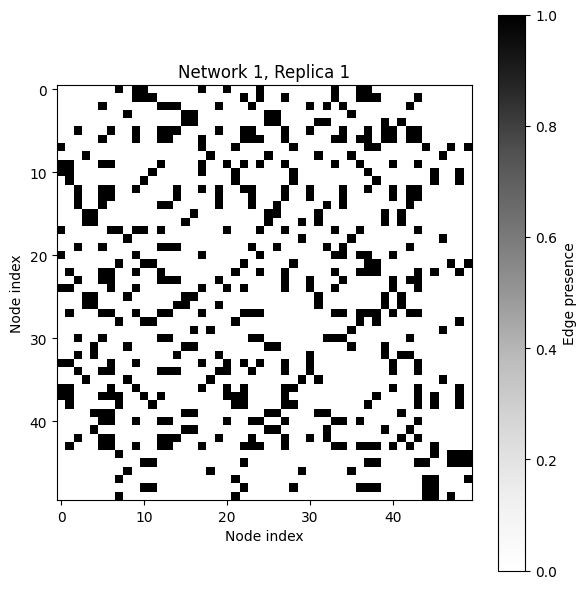

0 1


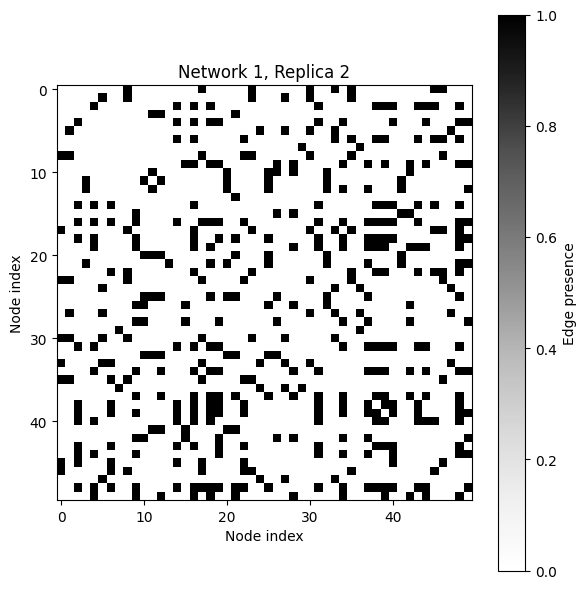

0 2


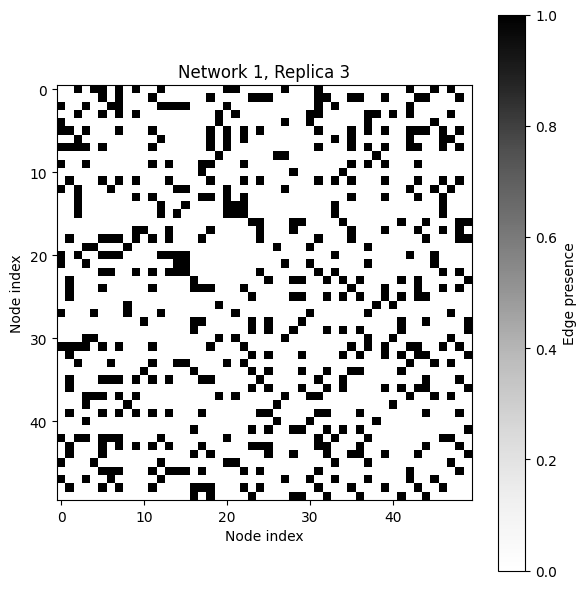

1 0


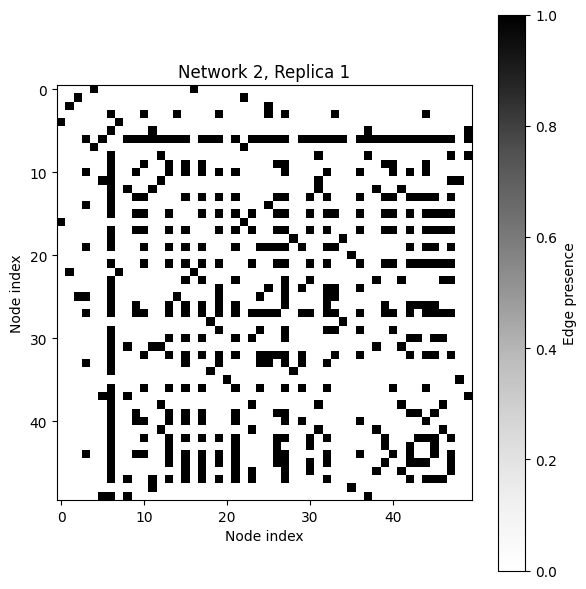

1 1


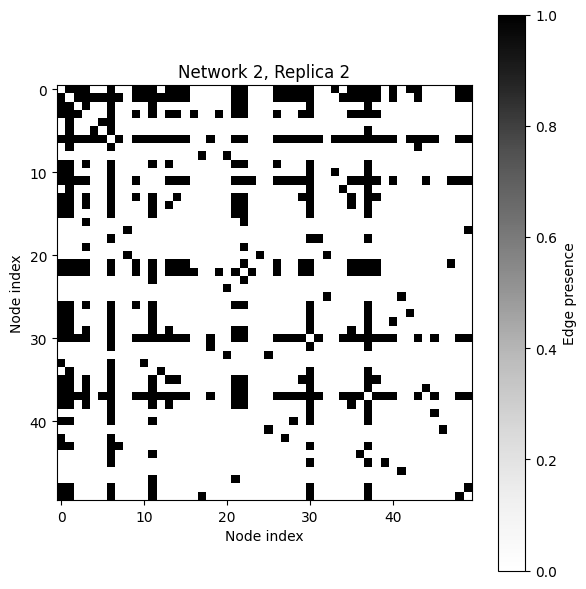

1 2


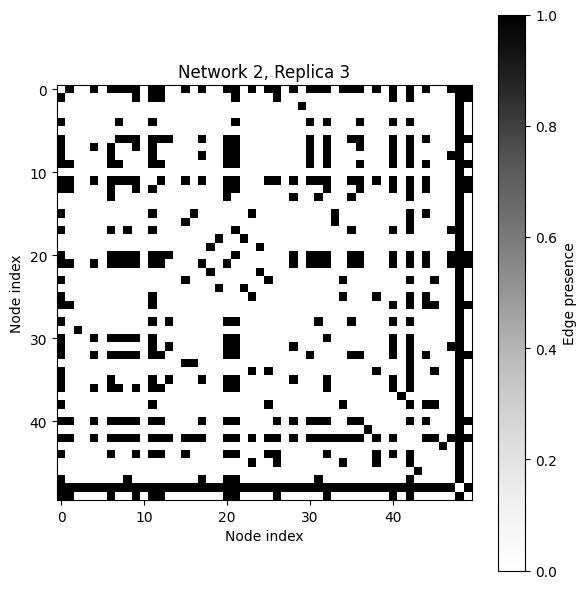

2 0


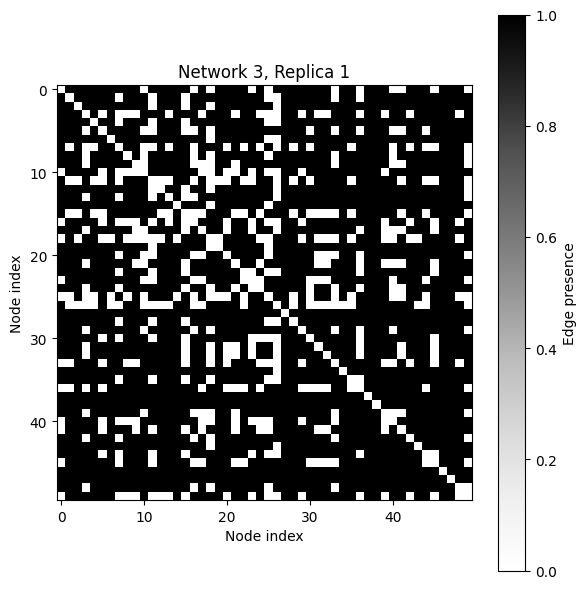

2 1


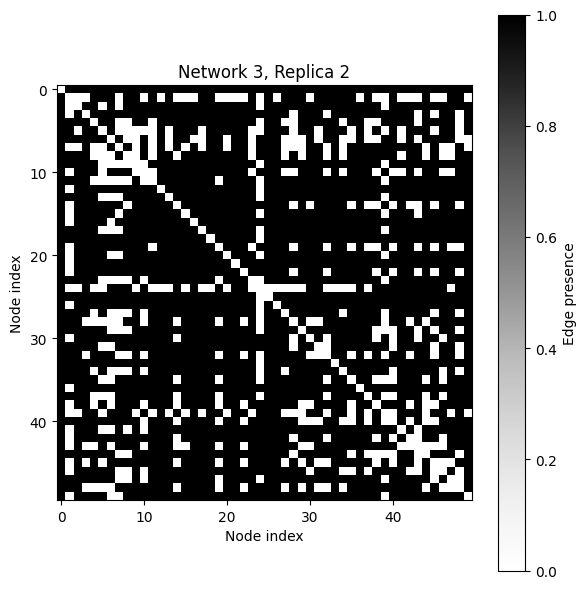

2 2


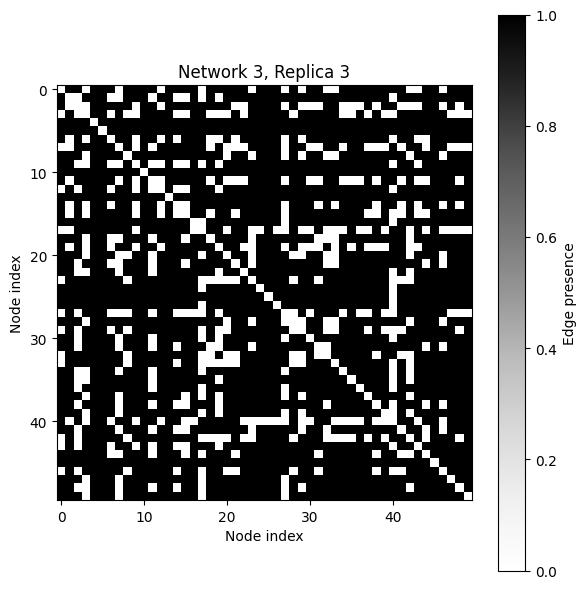

3 0


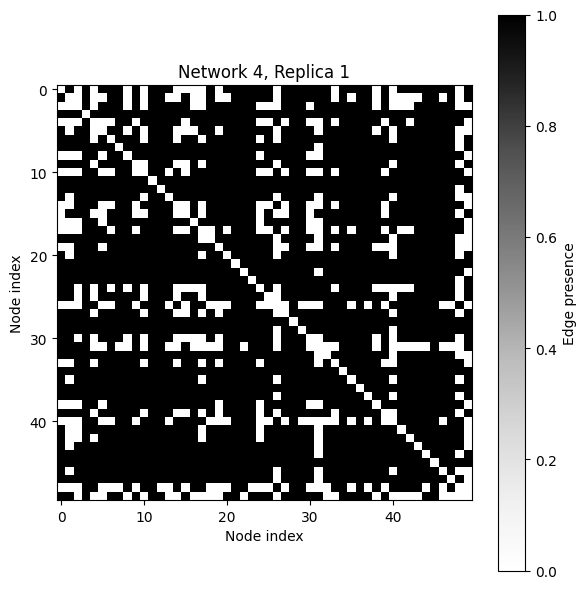

3 1


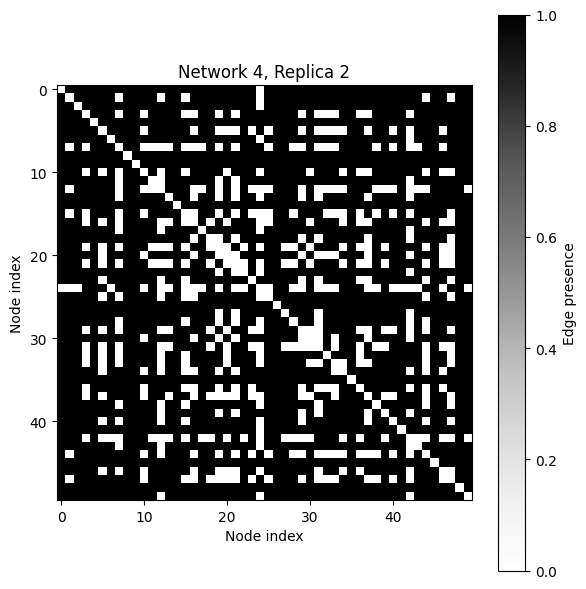

3 2


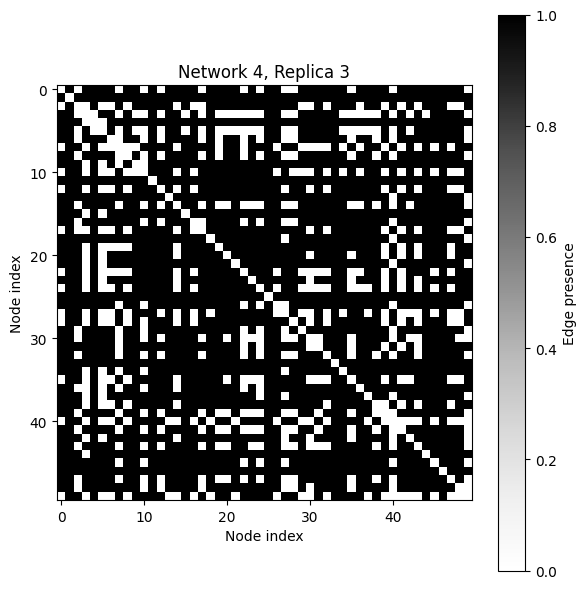

4 0


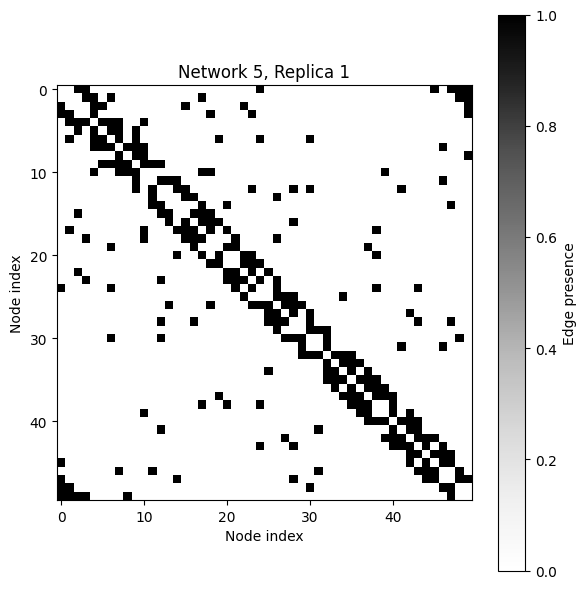

4 1


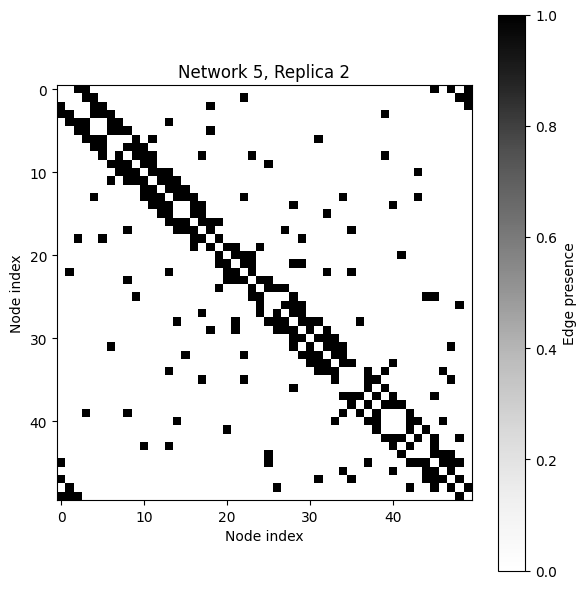

4 2


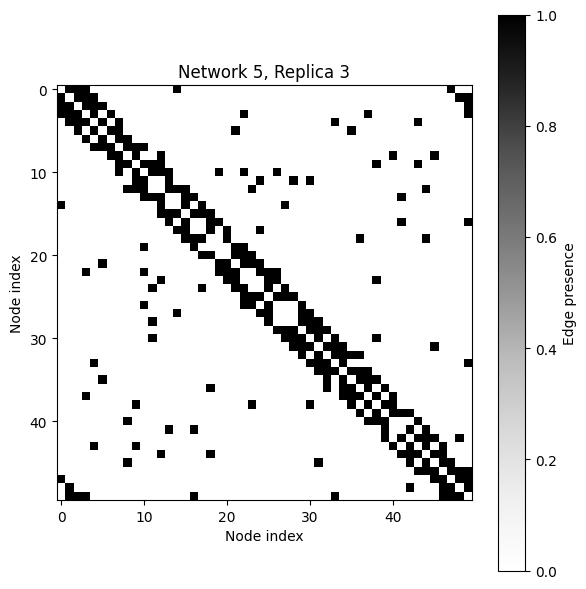

5 0


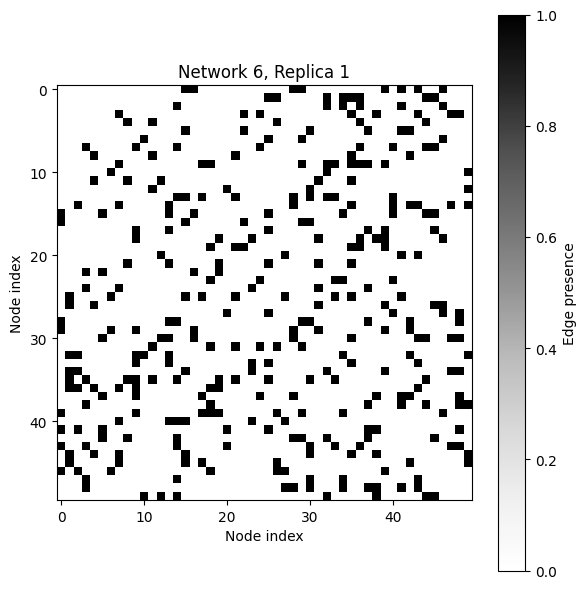

5 1


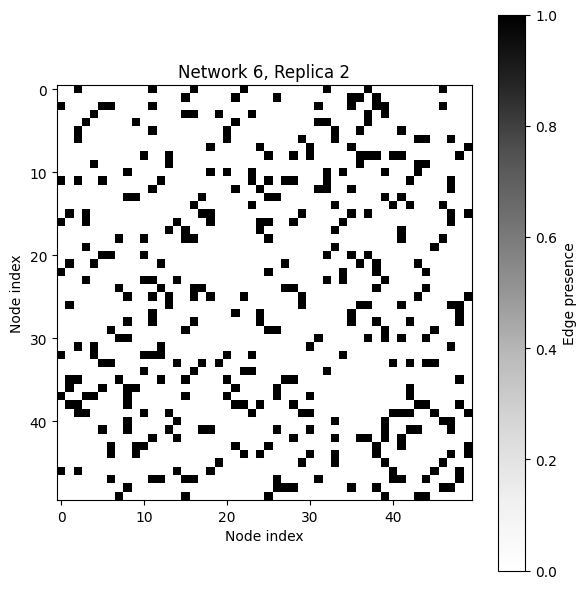

5 2


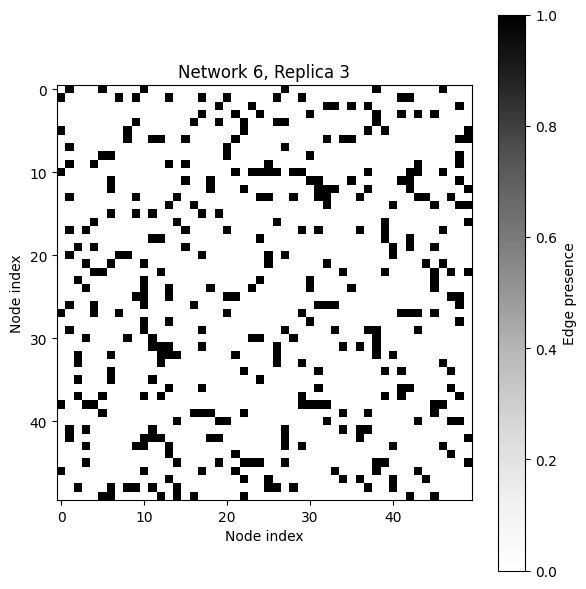

In [35]:
num_networks, num_replicas, N, _ = all_adj.shape

for i in range(num_networks):
    for r in range(num_replicas):
        print(i, r)
        A = all_adj[i, r]
        #break
        plt.figure(figsize=(6, 6))
        plt.imshow(A, cmap='Greys', interpolation='none')
        plt.colorbar(label='Edge presence')
        plt.title(f"Network {i+1}, Replica {r+1}")
        plt.xlabel("Node index")
        plt.ylabel("Node index")
        plt.tight_layout()
        plt.show()

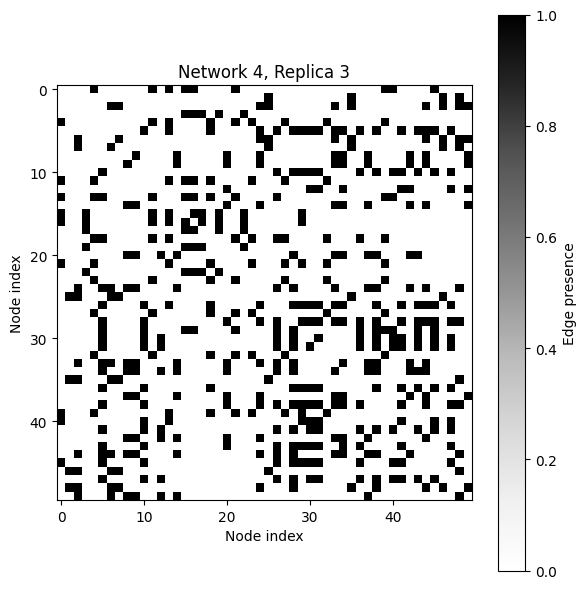

In [9]:
A = all_adj[0, 0]


plt.figure(figsize=(6, 6))
plt.imshow(A, cmap='Greys', interpolation='none')
plt.colorbar(label='Edge presence')
plt.title(f"Network {i+1}, Replica {r+1}")
plt.xlabel("Node index")
plt.ylabel("Node index")
plt.tight_layout()

plt.show()

TEST BUG: VARYING FREQ SPREAD


## Experiment Fully connected

### 1. but Without replication

Using device: CPU


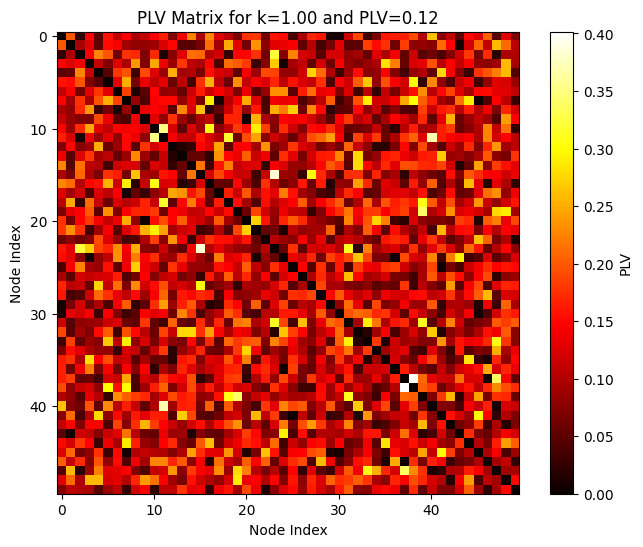

Estimated FA exponent α = 0.463
Using device: CPU


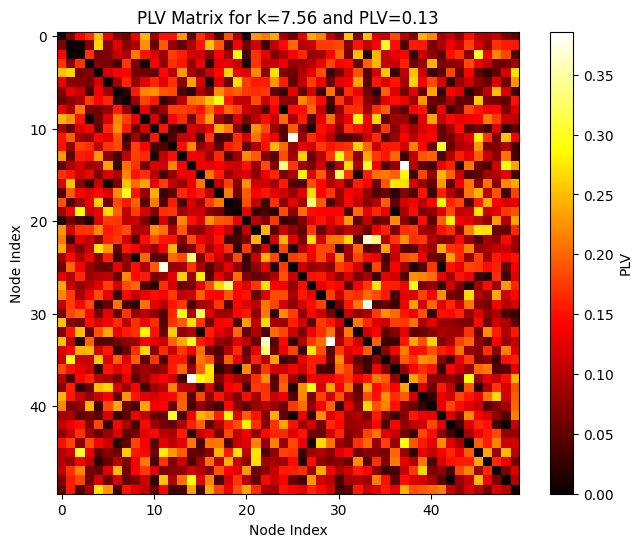

Estimated FA exponent α = 0.568
Using device: CPU


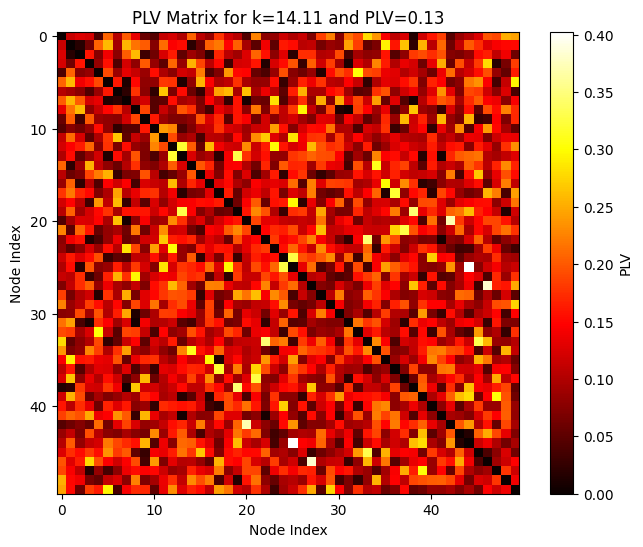

Estimated FA exponent α = 0.539
Using device: CPU


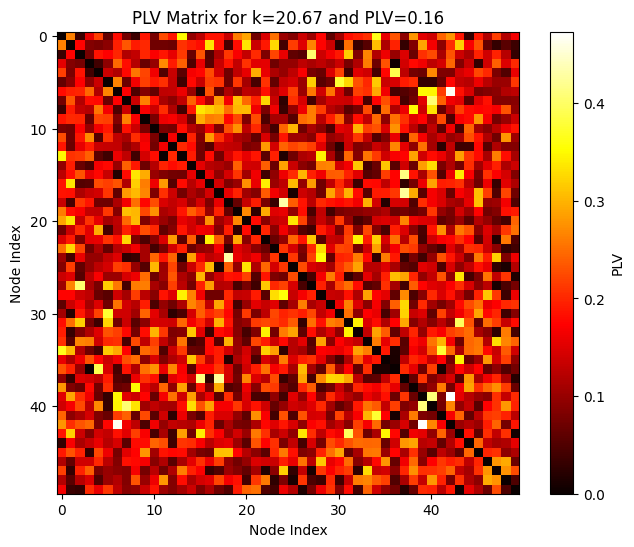

Estimated FA exponent α = 0.382
Using device: CPU


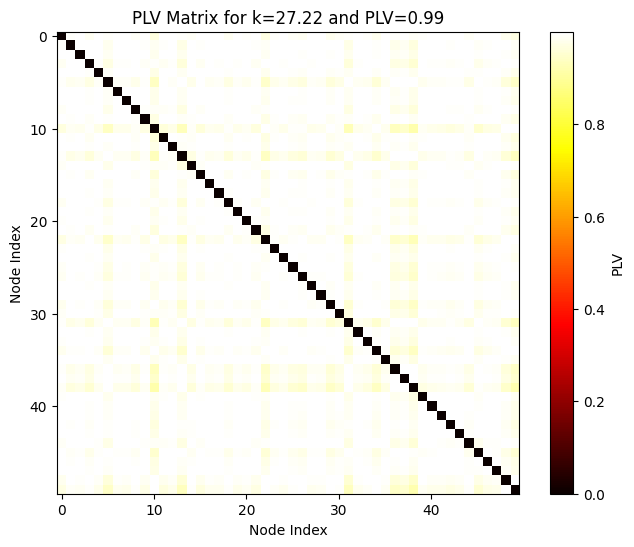

Estimated FA exponent α = 0.879
Using device: CPU


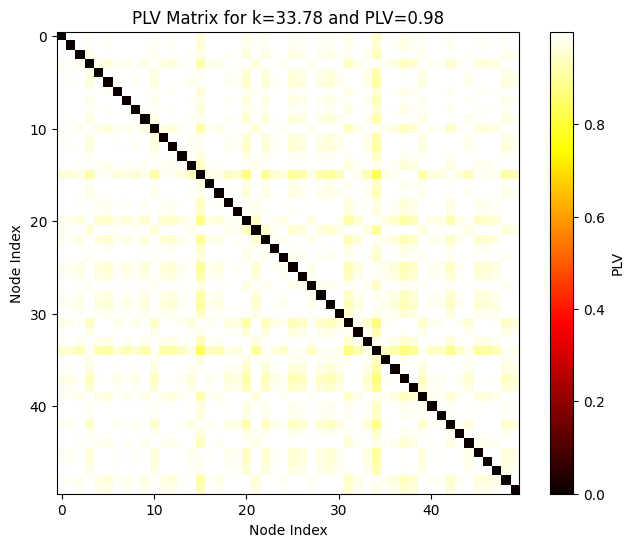

Estimated FA exponent α = 0.880
Using device: CPU


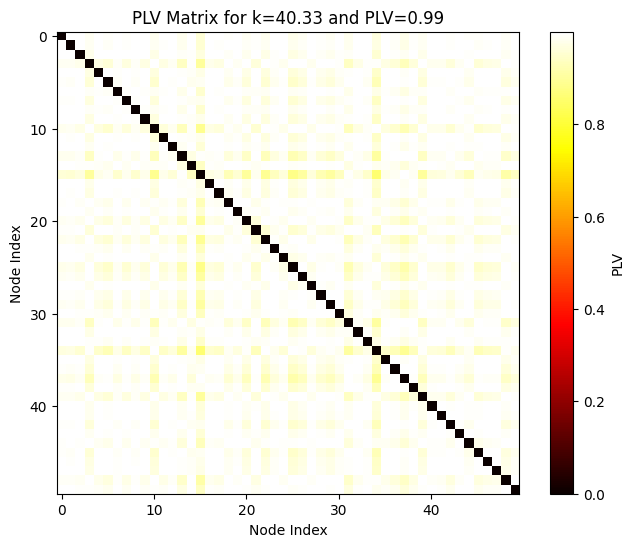

Estimated FA exponent α = 0.880
Using device: CPU


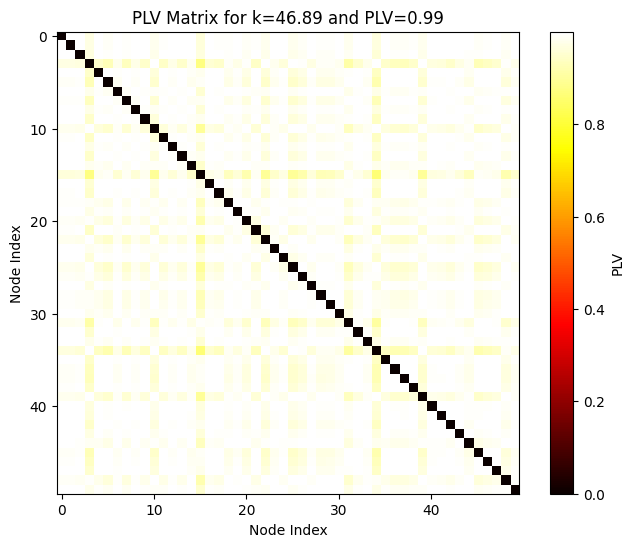

Estimated FA exponent α = 0.881
Using device: CPU


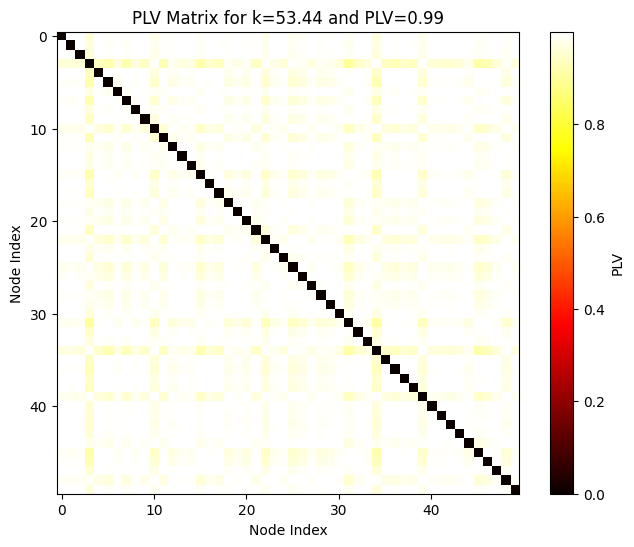

Estimated FA exponent α = 0.879
Using device: CPU


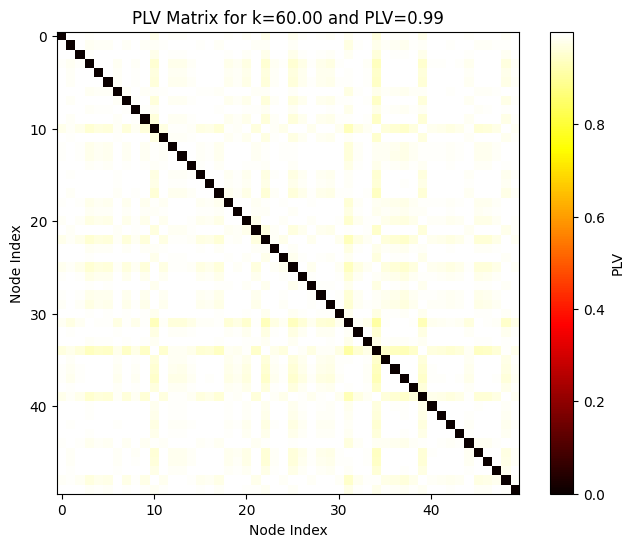

Estimated FA exponent α = 0.877
Using device: CPU


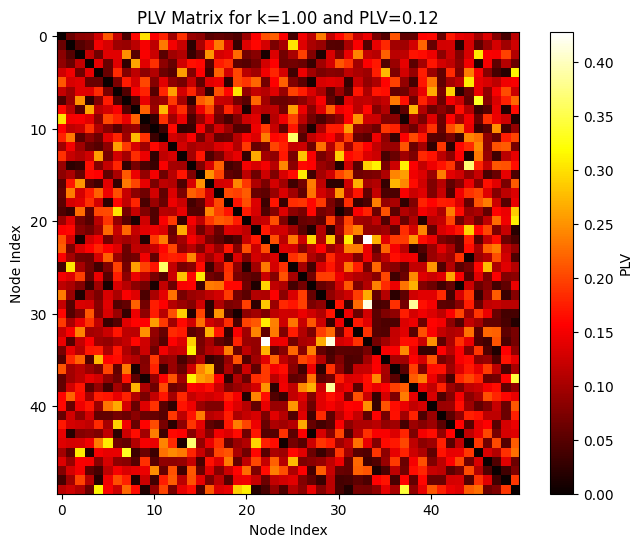

Estimated FA exponent α = 0.436
Using device: CPU


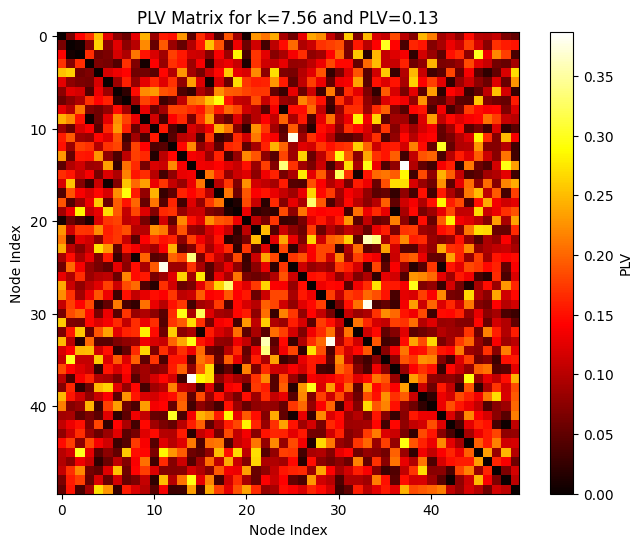

Estimated FA exponent α = 0.563
Using device: CPU


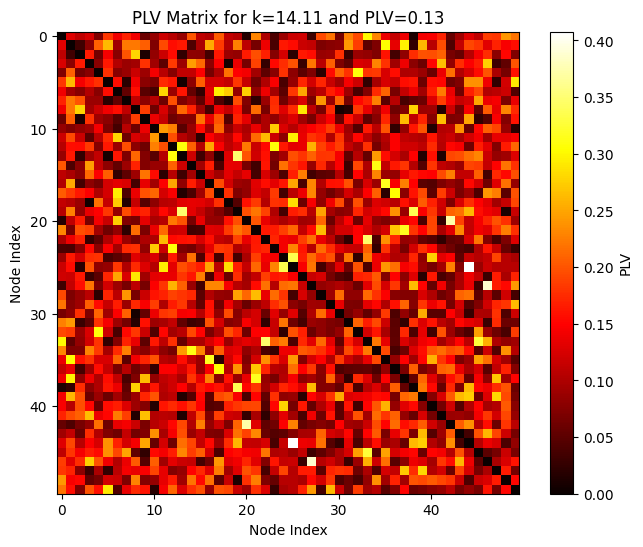

Estimated FA exponent α = 0.516
Using device: CPU


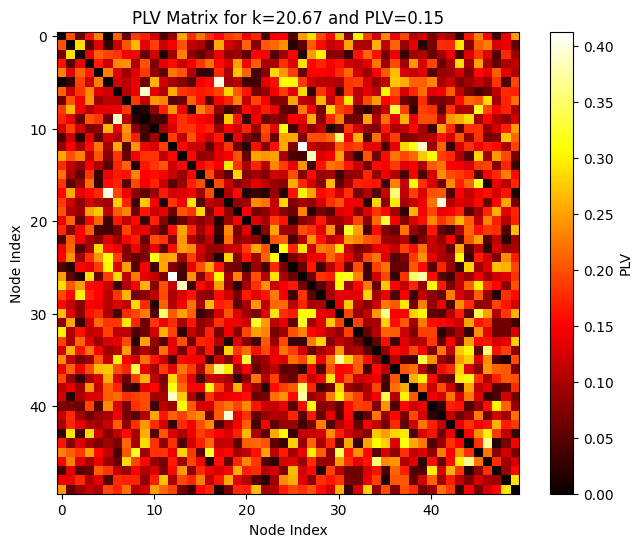

Estimated FA exponent α = 0.359
Using device: CPU


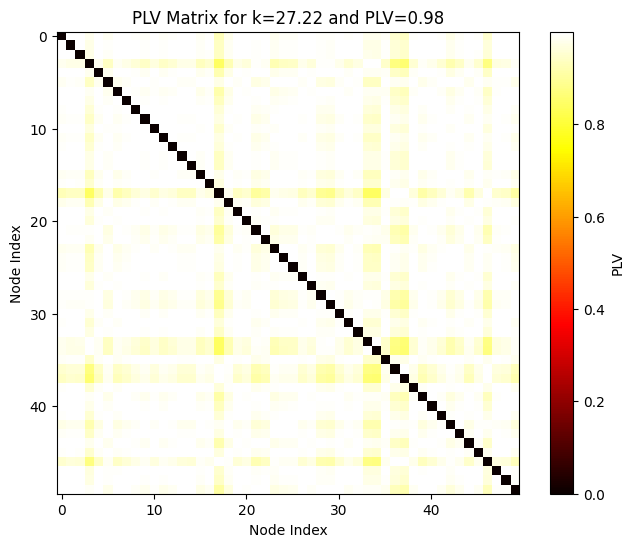

Estimated FA exponent α = 0.879
Using device: CPU


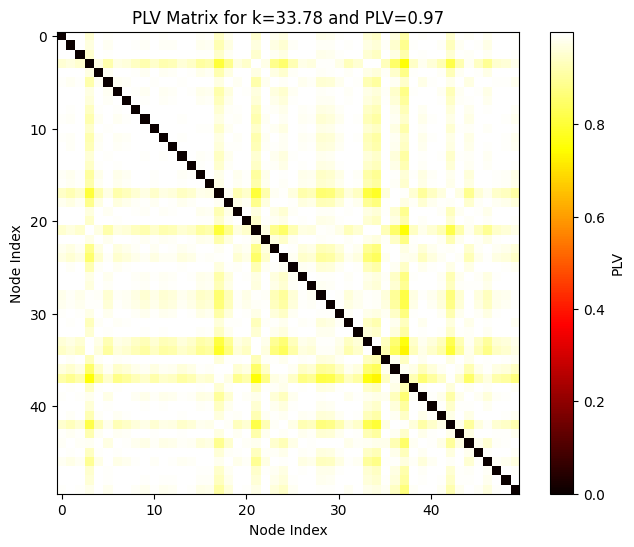

Estimated FA exponent α = 0.886
Using device: CPU


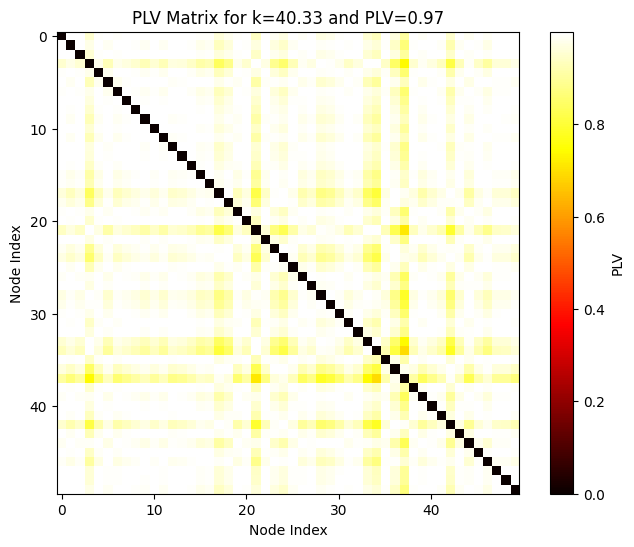

Estimated FA exponent α = 0.888
Using device: CPU


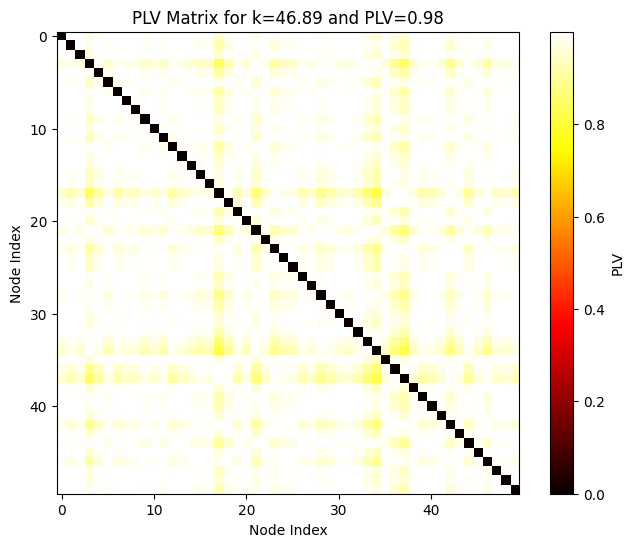

Estimated FA exponent α = 0.871
Using device: CPU


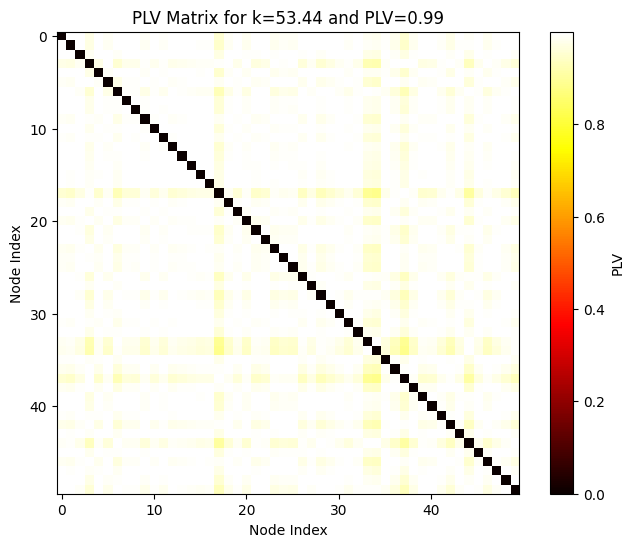

Estimated FA exponent α = 0.868
Using device: CPU


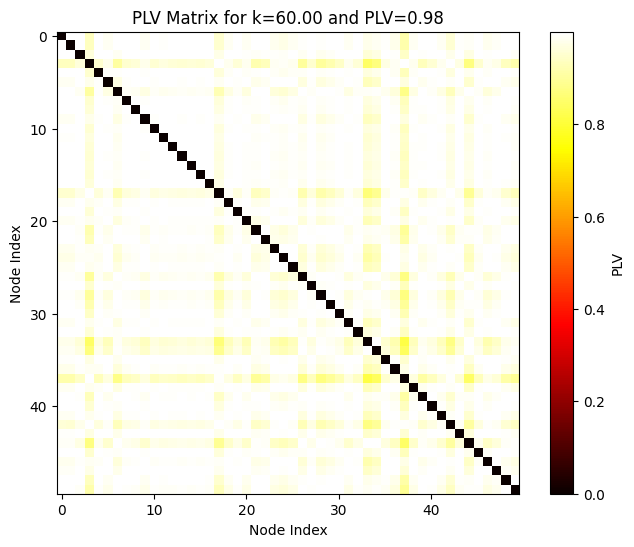

Estimated FA exponent α = 0.871
Using device: CPU


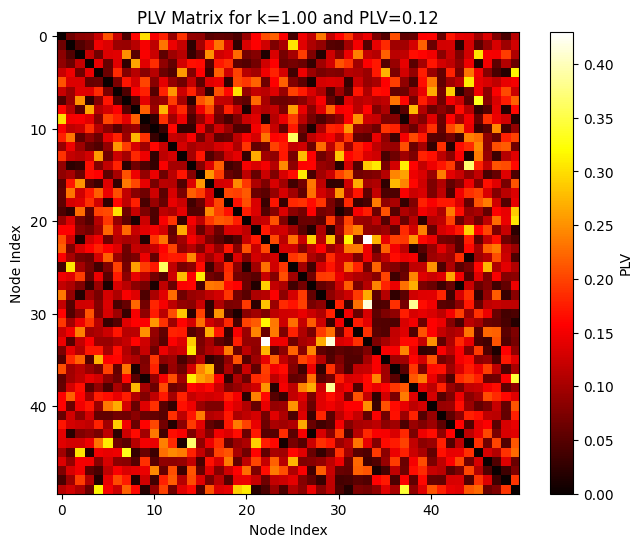

Estimated FA exponent α = 0.441
Using device: CPU


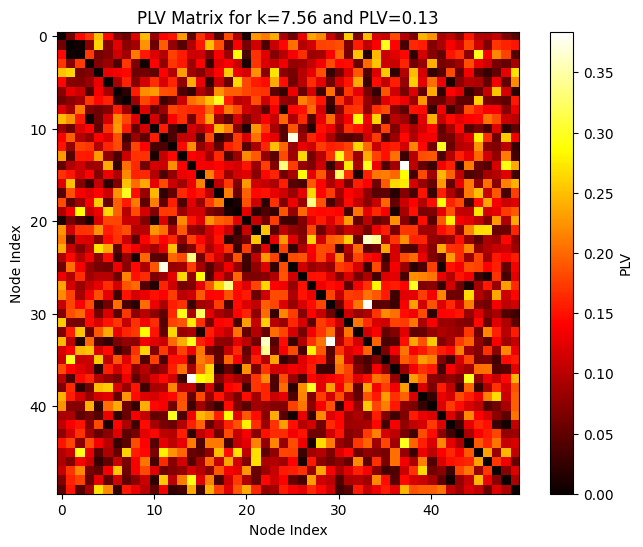

Estimated FA exponent α = 0.567
Using device: CPU


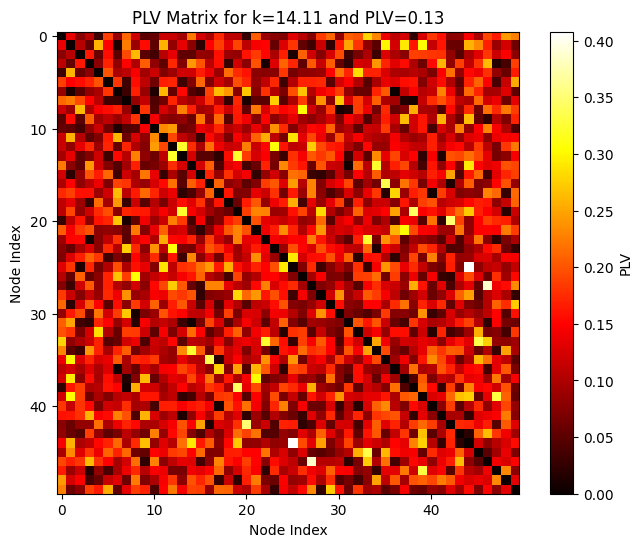

Estimated FA exponent α = 0.549
Using device: CPU


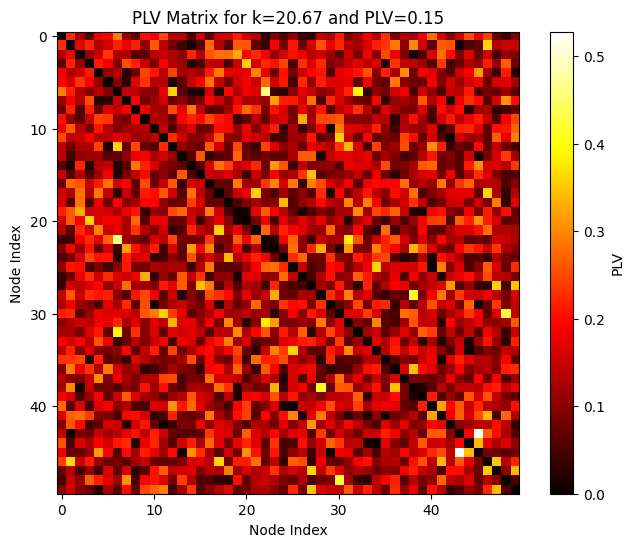

Estimated FA exponent α = 0.281
Using device: CPU


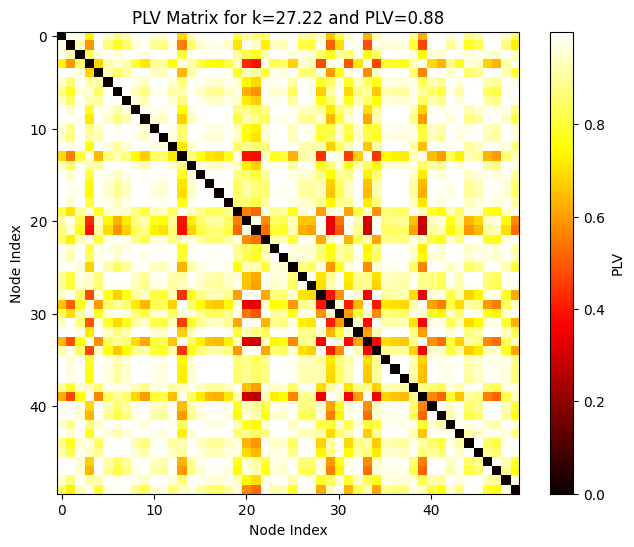

Estimated FA exponent α = 0.880
Using device: CPU


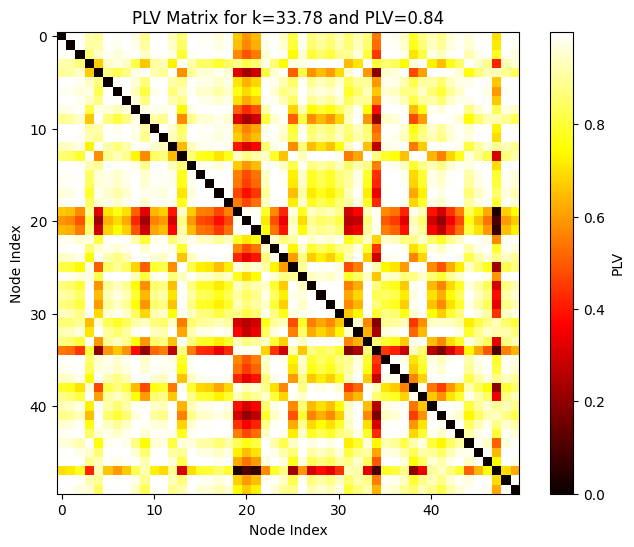

Estimated FA exponent α = 0.903
Using device: CPU


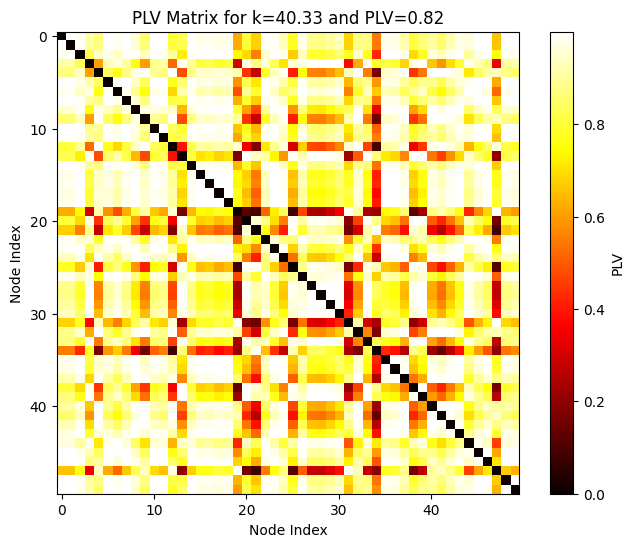

Estimated FA exponent α = 0.907
Using device: CPU


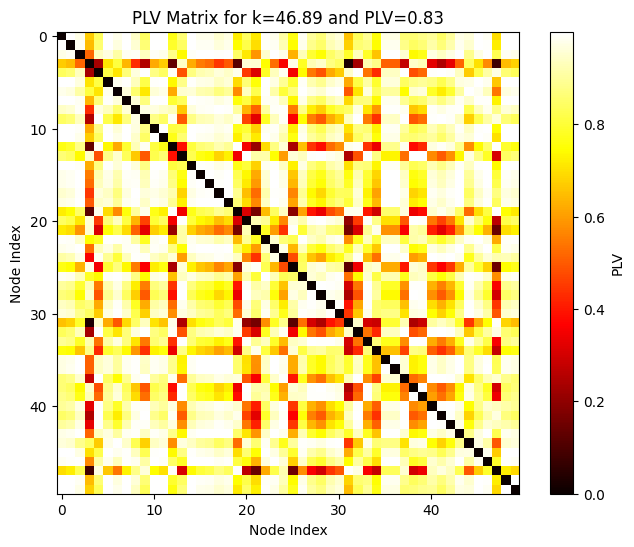

Estimated FA exponent α = 0.901
Using device: CPU


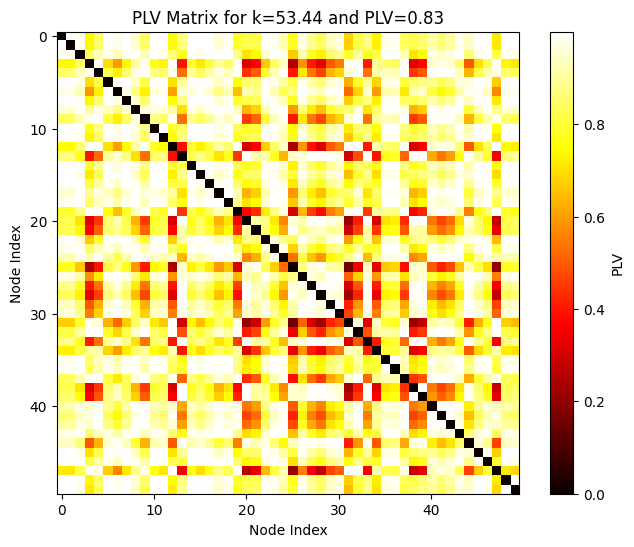

Estimated FA exponent α = 0.893
Using device: CPU


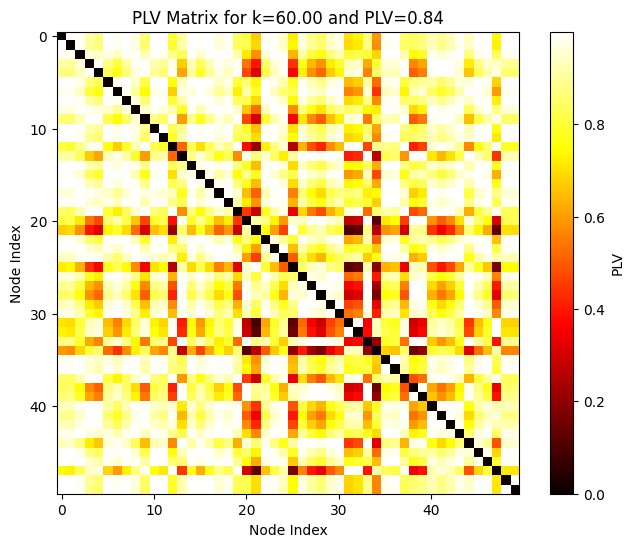

Estimated FA exponent α = 0.894
Using device: CPU


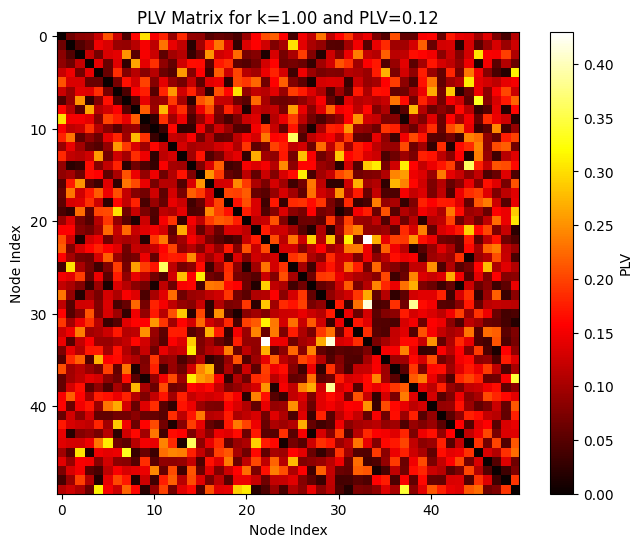

Estimated FA exponent α = 0.436
Using device: CPU


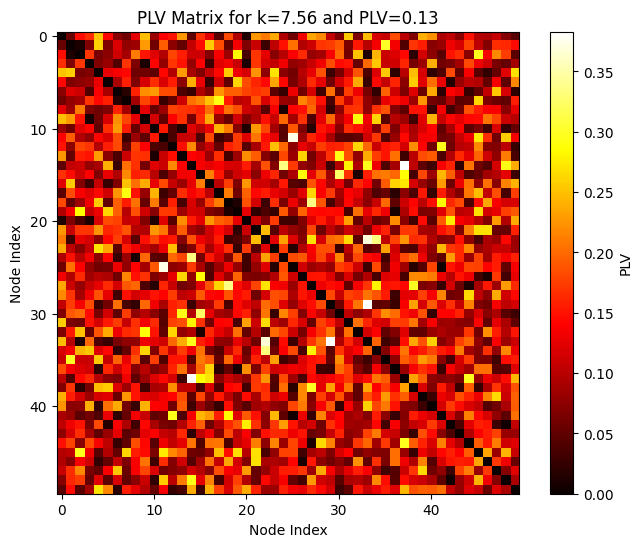

Estimated FA exponent α = 0.565
Using device: CPU


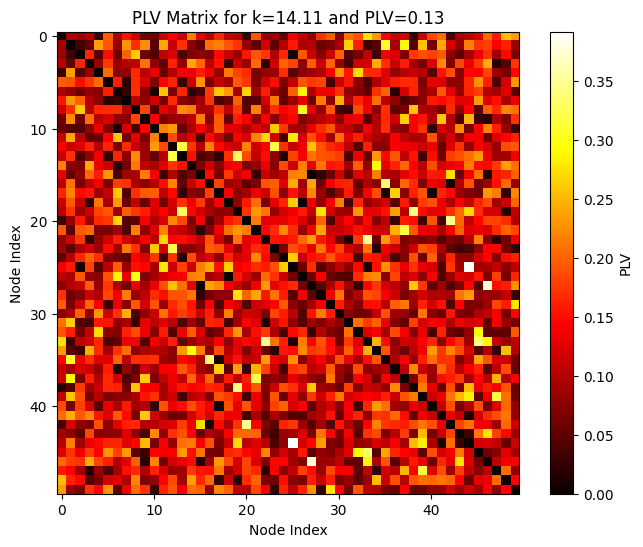

Estimated FA exponent α = 0.546
Using device: CPU


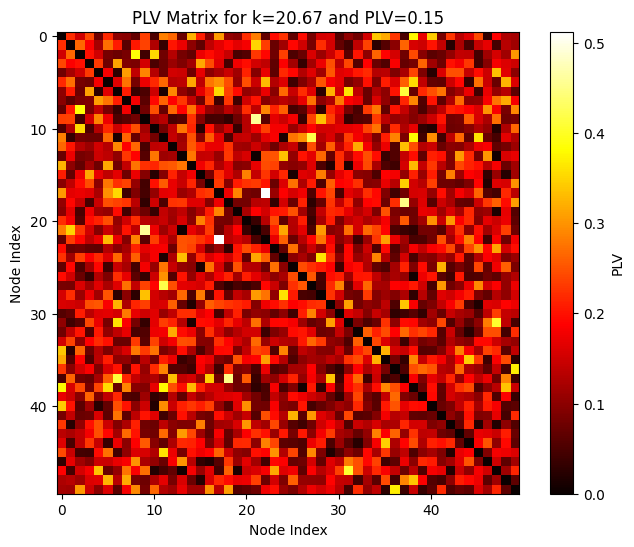

Estimated FA exponent α = 0.555
Using device: CPU


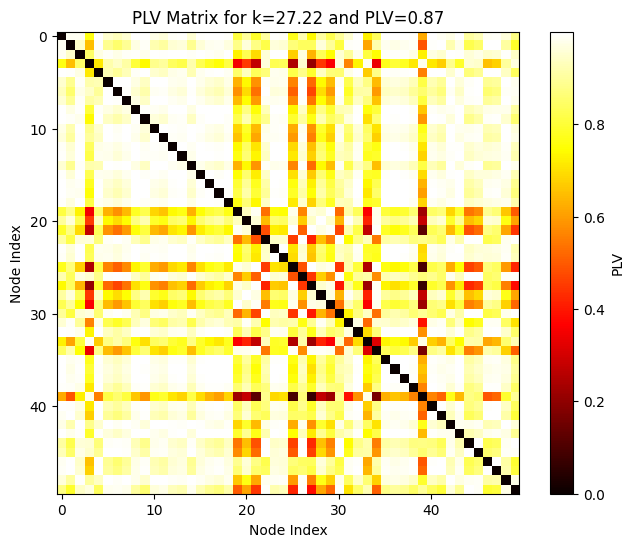

Estimated FA exponent α = 0.893
Using device: CPU


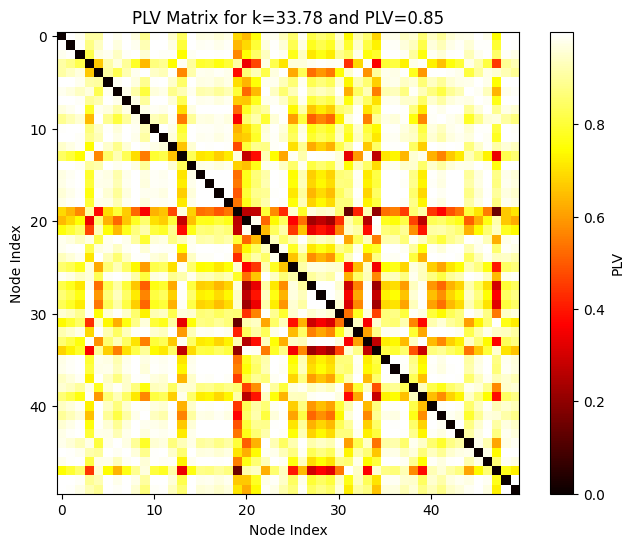

Estimated FA exponent α = 0.892
Using device: CPU


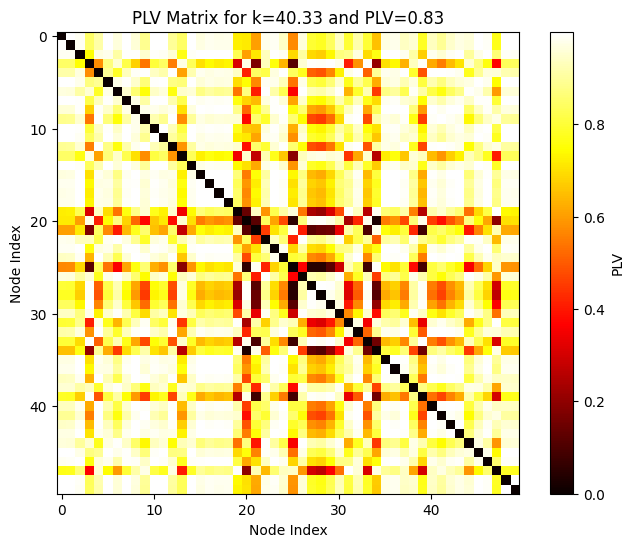

Estimated FA exponent α = 0.910
Using device: CPU


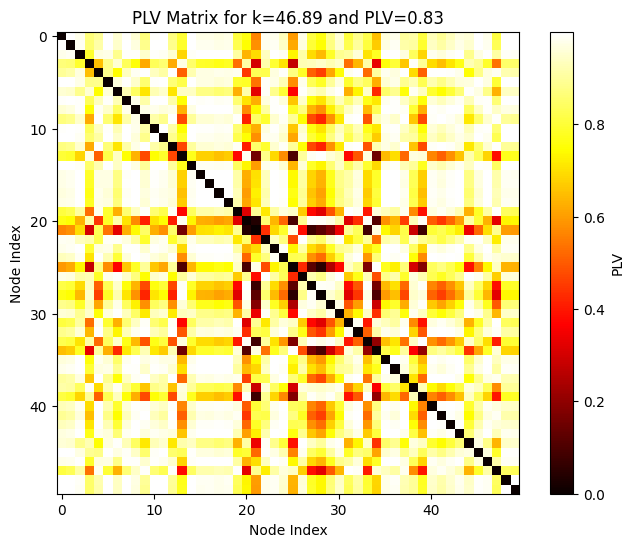

Estimated FA exponent α = 0.902
Using device: CPU


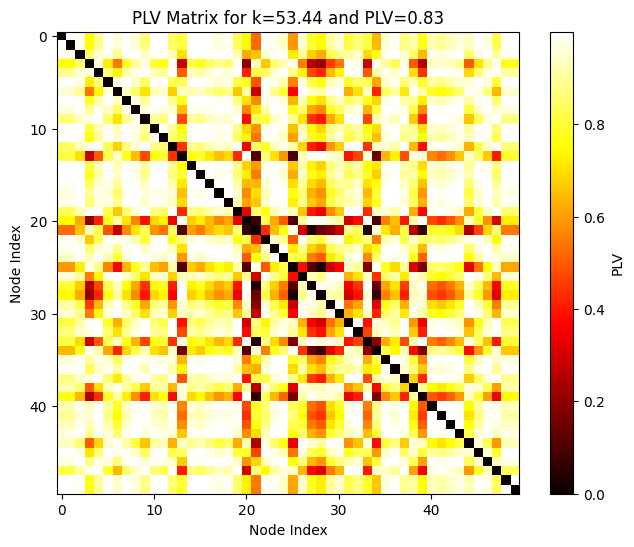

Estimated FA exponent α = 0.908
Using device: CPU


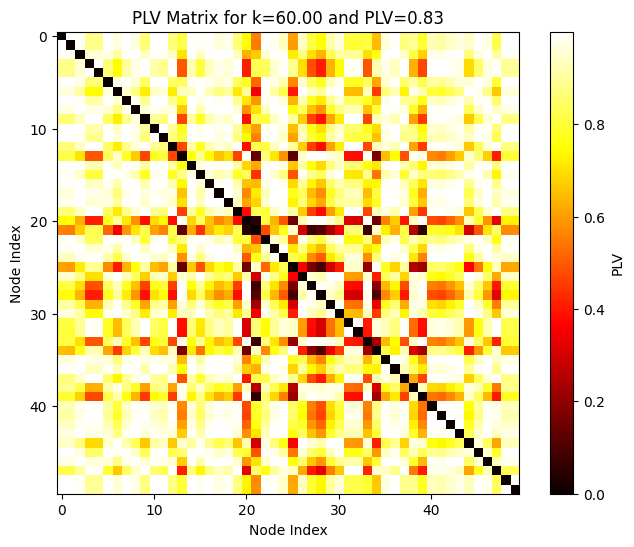

Estimated FA exponent α = 0.901


In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate Kuramoto model for each value of k
k_values = np.linspace(1, 60, 10)
# spread_values = np.linspace(3, 15, 10)

n_nodes = 50
n_oscillators = 100
sampling_rate = 200
frequency_spread = 3

weight_matrix = np.full((n_nodes, n_nodes), 1.0) # Fully connected !!
node_frequencies = [10.0] * n_nodes
use_cuda = True
time = 10  # simulate 10 seconds of activity

#for frequency_spread in spread_values:
order_matrix = np.zeros((4, 10))  # Reset for each frequency spread
variability_matrix = np.zeros((4, 10))  # Reset for each frequency spread
plv_matrix = np.zeros((4, 10))
dfa_matrix = np.zeros((4, 10))
fa_matrix = np.zeros((4, 10))



for i in np.arange(0,4):
    A = all_adj[i, 2]

    #for frequency_spread in spread_values:
    # order_results = []  # Reset for each frequency spread
    # variability_results = []  # Reset for each frequency spread
    # plv_results = []
    # dfa_values = []
    # fa_values = []
    
    for j, k in enumerate(k_values):
        # Simulate the Kuramoto model
        model_3 = KuramotoFast(n_nodes=n_nodes,
                                n_oscillators=n_oscillators,
                                k_list=[k] * n_nodes,
                                weight_matrix= A ,
                                node_frequencies=node_frequencies,
                                sampling_rate=sampling_rate,
                                frequency_spread=frequency_spread,
                                use_cuda=use_cuda)
    
        phase_data = model_3.simulate(time=time)
        phase_data = phase_data[:, 650:]  # remove transient
        n_timepoints = phase_data.shape[1]
    
            
        order = np.abs(np.mean(phase_data, axis=0))  # time series
        order_mean = order.mean()
        order_std = order.std()
    
        # phase_data: (N_nodes, T) complex phasors
        inst_theta = np.angle(phase_data).T
        plv_mat = plv_matrix_vectorized(inst_theta)
    
        # Remove diagonal
        #Extract only upper triangle (no diagonal)
    
        np.fill_diagonal(plv_mat, 0)
        plv_order = plv_mat[np.triu_indices_from(plv_mat, k=1)].mean()
        #plv_results.append(plv_order)
        plv_matrix[i, j] = plv_order
        
        
        #Plotting PLV matrix
        plt.figure(figsize=(8, 6))
        plt.imshow(plv_mat, cmap='hot', interpolation='nearest')
        plt.colorbar(label='PLV')
        plt.title(f'PLV Matrix for k={k:.2f} and PLV={plv_order:.2f}')
        plt.xlabel('Node Index')
        plt.ylabel('Node Index')
        plt.show()
    
        # Compute DFA
        scales = dfa_scales() 
        module = np.abs(phase_data)
        global_phasor = module.mean(axis=0)       
        alpha = DFA(global_phasor)
        
        #dfa_values.append(alpha[0])
        dfa_matrix[i, j] = alpha[0]
    
        # Compute FA metric
        fa = FA_metric(global_phasor, scales)
        #fa_values.append(fa[1])
        fa_matrix[i,j] = fa[1]    
        
        # Storing the values
        #order_results.append(order_mean)
        #variability_results.append(order_std)

        order_matrix[i, j] = order_mean
        variability_matrix[i, j] = order_std



## ## 2. With replication2. With replication

In [11]:
order_matrix

array([[[0.01277315, 0.01623864, 0.01892971, 0.02171603, 0.11885887,
         0.20878044, 0.1800438 , 0.07280871, 0.06933919, 0.06849238],
        [0.01346631, 0.01622584, 0.01891843, 0.02571477, 0.12785621,
         0.20922777, 0.19253099, 0.13869503, 0.13159074, 0.1202664 ],
        [0.01344134, 0.01619119, 0.01886464, 0.02374355, 0.13026373,
         0.22425079, 0.17004129, 0.04886927, 0.06222089, 0.05936662]],

       [[0.01345047, 0.01620766, 0.01890468, 0.02128587, 0.04199531,
         0.10246252, 0.17546602, 0.22119218, 0.22056673, 0.22597824],
        [0.013449  , 0.01622234, 0.01893347, 0.02789389, 0.10659415,
         0.18333605, 0.10233637, 0.07665094, 0.0432669 , 0.03879232],
        [0.01344426, 0.0162396 , 0.01900079, 0.02483992, 0.13966678,
         0.24254762, 0.24060926, 0.19536829, 0.19380032, 0.1896164 ]],

       [[0.01379057, 0.01674597, 0.01986137, 0.03192844, 0.53735882,
         0.74516046, 0.64986438, 0.40845349, 0.38421342, 0.36152673],
        [0.01378292, 0.

In [39]:
len(all_adj)

6

In [40]:
# Simulate Kuramoto model for each value of k
k_values = np.linspace(1, 60, 10)
n_nodes = 50
n_oscillators = 100
sampling_rate = 200
frequency_spread = 3

weight_matrix = np.full((n_nodes, n_nodes), 1.0) # Fully connected !!
node_frequencies = [10.0] * n_nodes
use_cuda = torch.cuda.is_available()
time = 10  # simulate 10 seconds of activity

# Store here:
order_matrix = np.zeros((len(all_adj), 3, len(k_values)))  # ← (4, 3, 10)
variability_matrix = np.zeros((len(all_adj), 3, len(k_values)))
plv_matrix = np.zeros((len(all_adj), 3, len(k_values)))
dfa_matrix = np.zeros((len(all_adj), 3, len(k_values)))
fa_matrix = np.zeros((len(all_adj), 3, len(k_values)))


print(all_adj.shape)

for treatment in range(len(all_adj)):
    #treatment = 0    
    print("treatment", treatment)
    trea = all_adj[treatment] # first, second treatmetn
    print("trea ", trea.shape)
    
    for replica in range(3):
        
        print("replica: ", replica)
        print(trea[replica,:,:].shape) # 
    
        for k_idx, k in enumerate(k_values):
            random_seed = int(np.random.randint(0, 1e6))
            model = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k] * n_nodes,
                weight_matrix=trea[replica,:,:],
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                random_seed = random_seed ,
                use_cuda=use_cuda
            )
    
            phase_data = model.simulate(time=time)
            phase_data = phase_data[:, 650:]
    
            order_ts = np.abs(np.mean(phase_data, axis=0))
            order_mean = order_ts.mean()
            order_std = order_ts.std()


            # phase_data: (N_nodes, T) complex phasors
            inst_theta = np.angle(phase_data).T
            plv_mat = plv_matrix_vectorized(inst_theta)
            np.fill_diagonal(plv_mat, 0)
            plv_order = plv_mat[np.triu_indices_from(plv_mat, k=1)].mean()
        
            # Compute DFA
            scales = dfa_scales() 
            module = np.abs(phase_data)
            global_phasor = module.mean(axis=0)       
            alpha = DFA(global_phasor)

            # Compute FA metric
            fa = FA_metric(global_phasor, scales)
             
           
    
            # ← GUARDAR EN LA POSICIÓN CORRECTA
            order_matrix[treatment, replica, k_idx] = order_mean
            variability_matrix[treatment, replica, k_idx] = order_std
            plv_matrix[treatment, replica, k_idx] = plv_order
            dfa_matrix[treatment, replica, k_idx] = alpha[0]
            fa_matrix[treatment, replica, k_idx] = fa[1] 
                
np.savez(
    "kuramoto_results12Nov_mini.npz",
    order_matrix=order_matrix,
    variability_matrix=variability_matrix,
    plv_matrix=plv_matrix,
    dfa_matrix=dfa_matrix,
    fa_matrix=fa_matrix,
    k_values=k_values,
    params=dict(
        n_nodes=n_nodes,
        n_oscillators=n_oscillators,
        sampling_rate=sampling_rate,
        frequency_spread=frequency_spread,
        time=time,
        use_cuda=use_cuda,
    )
)

print("Saved all matrices to kuramoto_results.npz")
            

(6, 3, 50, 50)
treatment 0
trea  (3, 50, 50)
replica:  0
(50, 50)
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.370
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.608
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.291
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.610
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.880
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.881
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.883
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.883
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.884
Saved all matrices to kuramoto_results.npz


In [41]:
fa_matrix.shape #order_results5_02

(6, 3, 10)

In [45]:
len(all_adj)

6

Treatment #: 0
  Replica 0: Max variability at k = 33.78
  Replica 1: Max variability at k = 33.78
  Replica 2: Max variability at k = 40.33


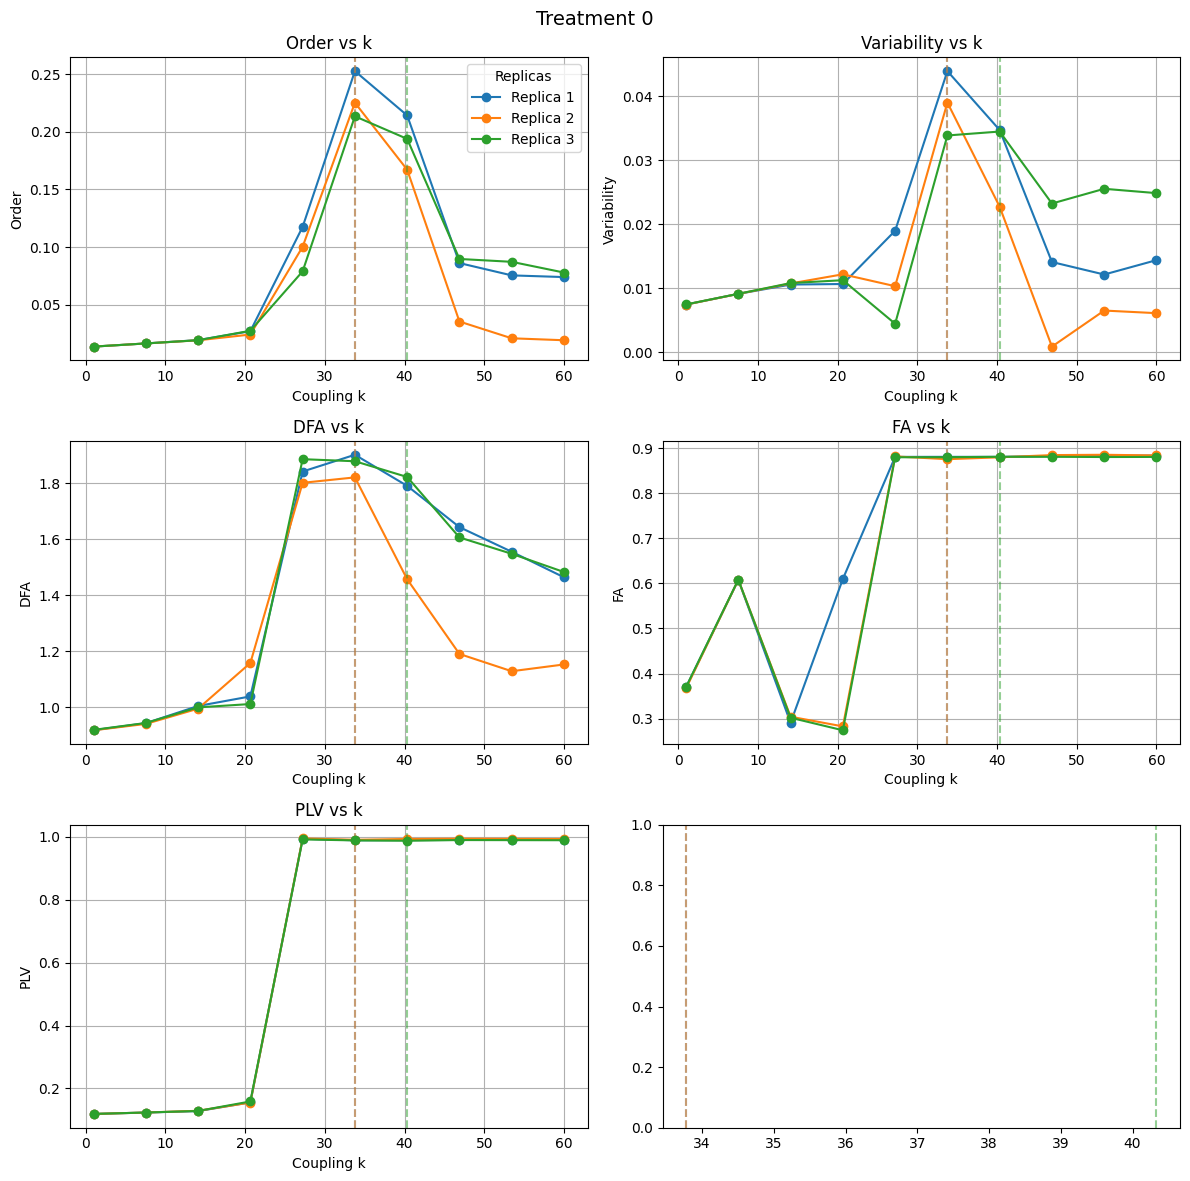

Treatment #: 1
  Replica 0: Max variability at k = 60.00
  Replica 1: Max variability at k = 46.89
  Replica 2: Max variability at k = 40.33


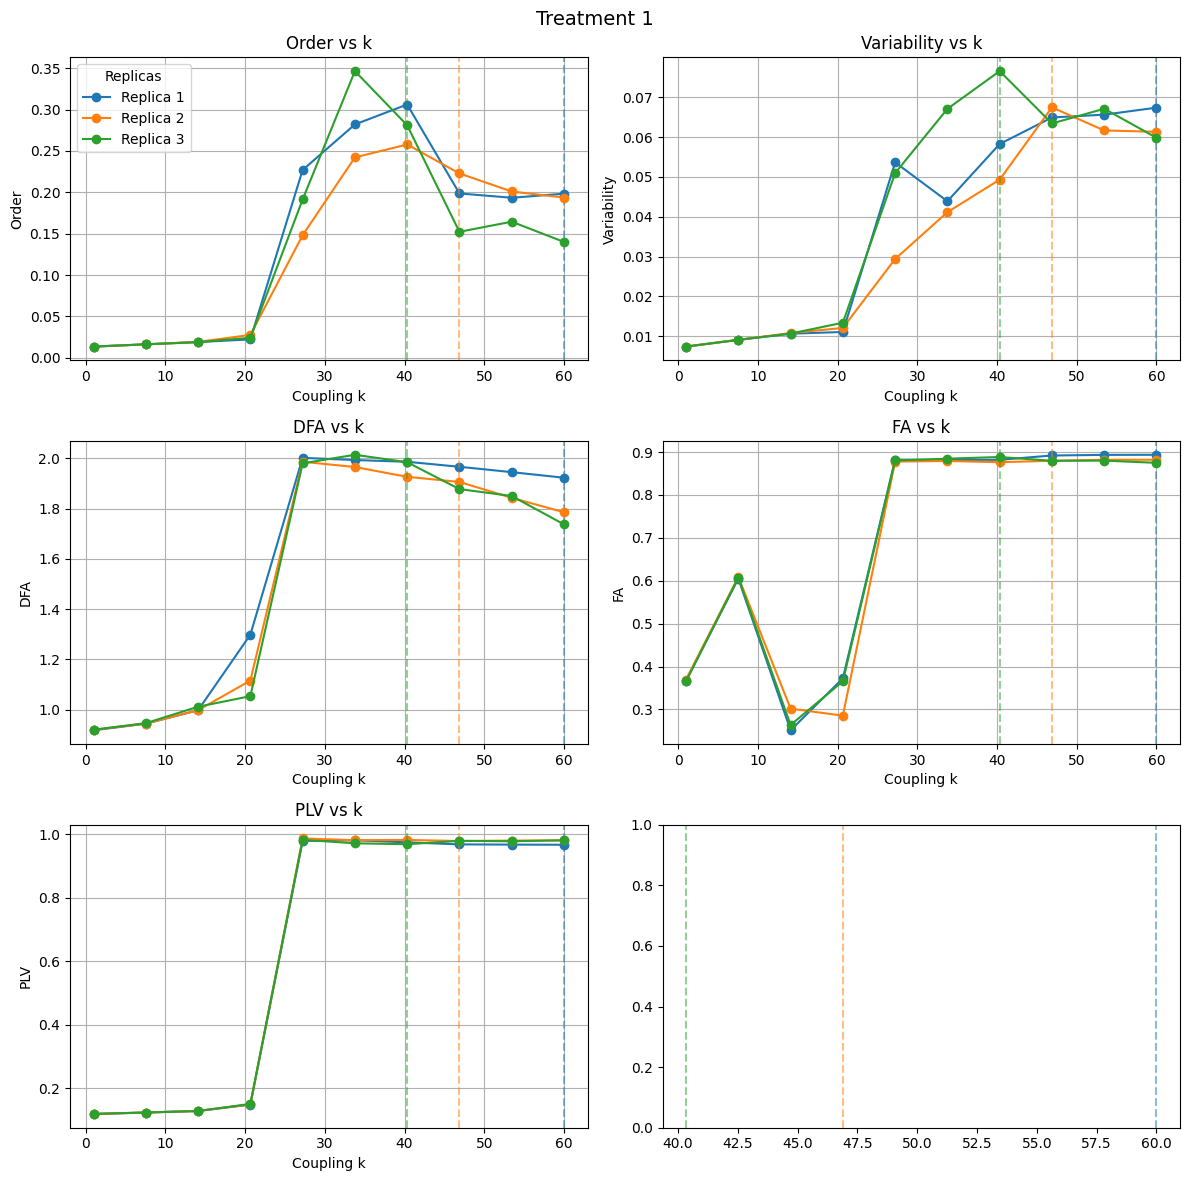

Treatment #: 2
  Replica 0: Max variability at k = 46.89
  Replica 1: Max variability at k = 46.89
  Replica 2: Max variability at k = 60.00


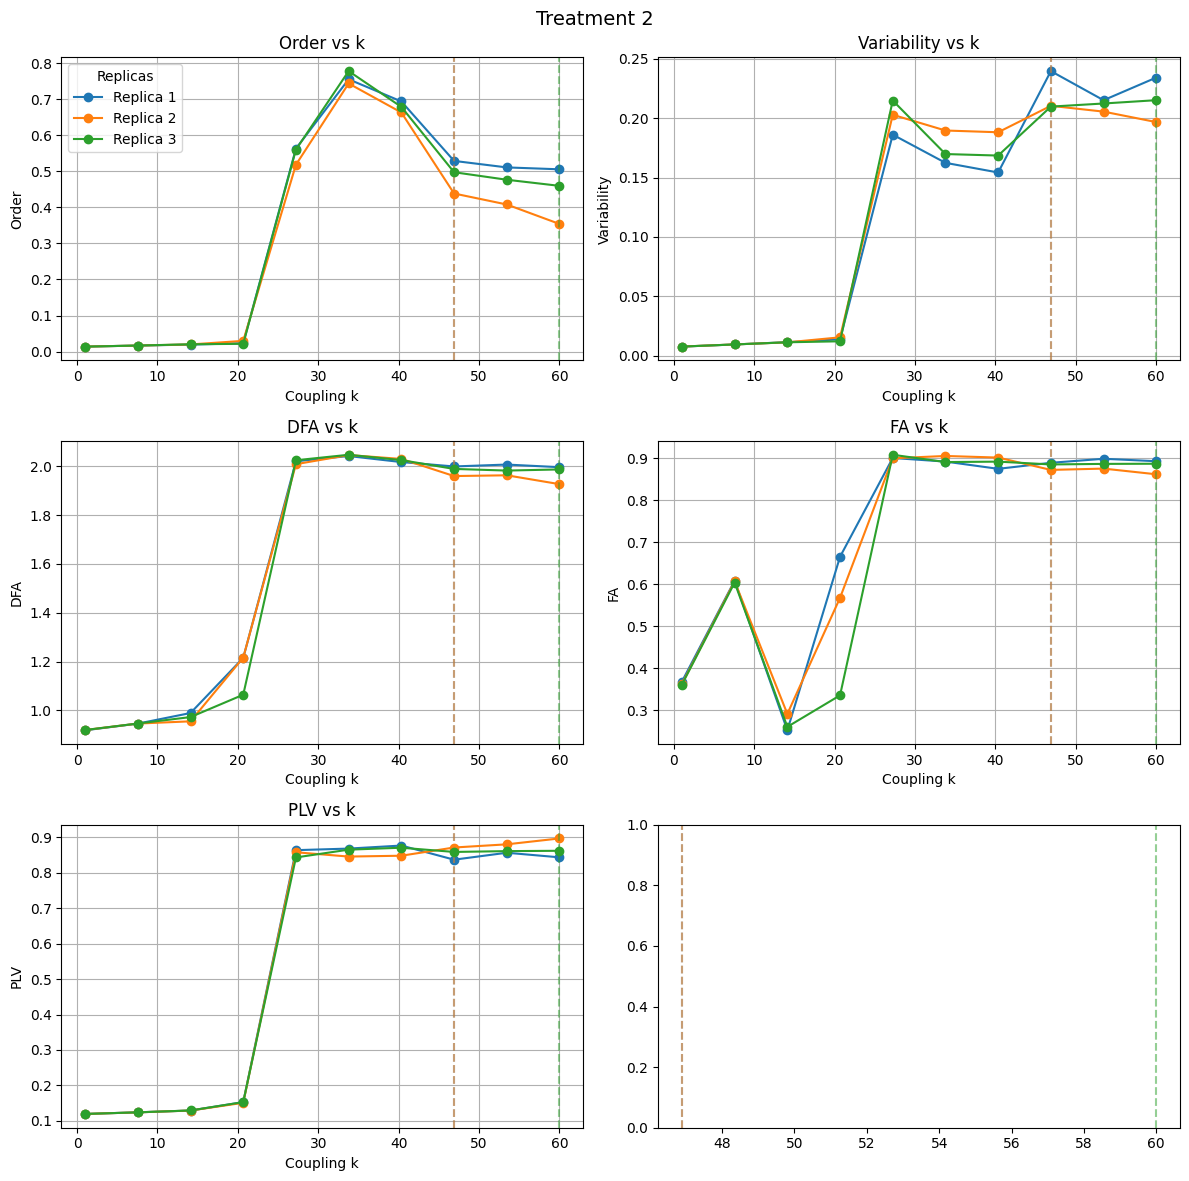

Treatment #: 3
  Replica 0: Max variability at k = 60.00
  Replica 1: Max variability at k = 46.89
  Replica 2: Max variability at k = 60.00


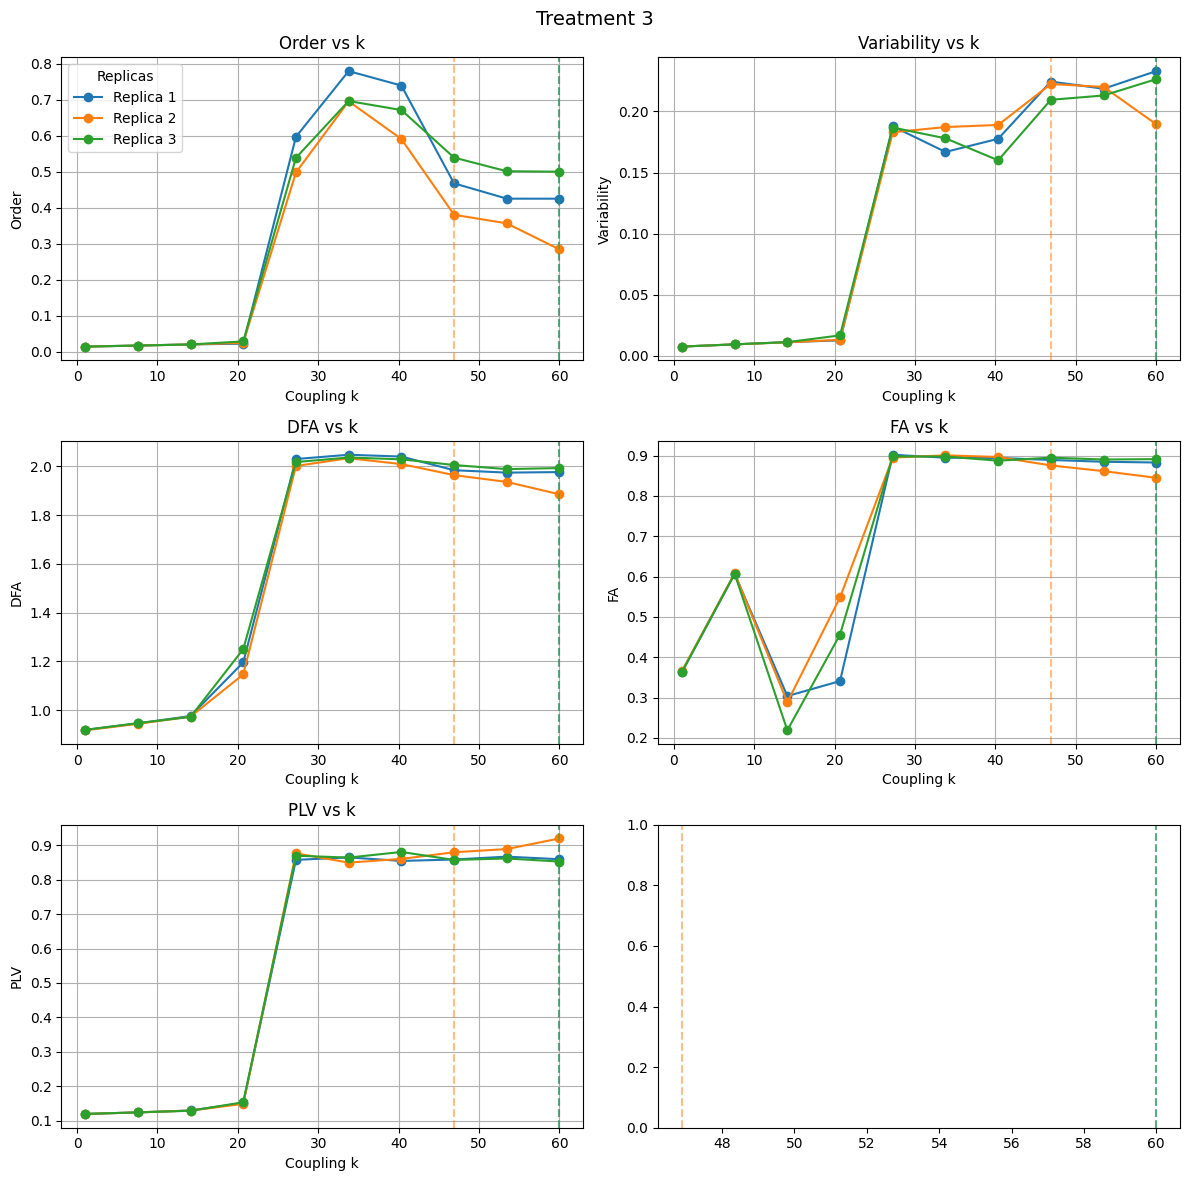

Treatment #: 4
  Replica 0: Max variability at k = 60.00
  Replica 1: Max variability at k = 60.00
  Replica 2: Max variability at k = 46.89


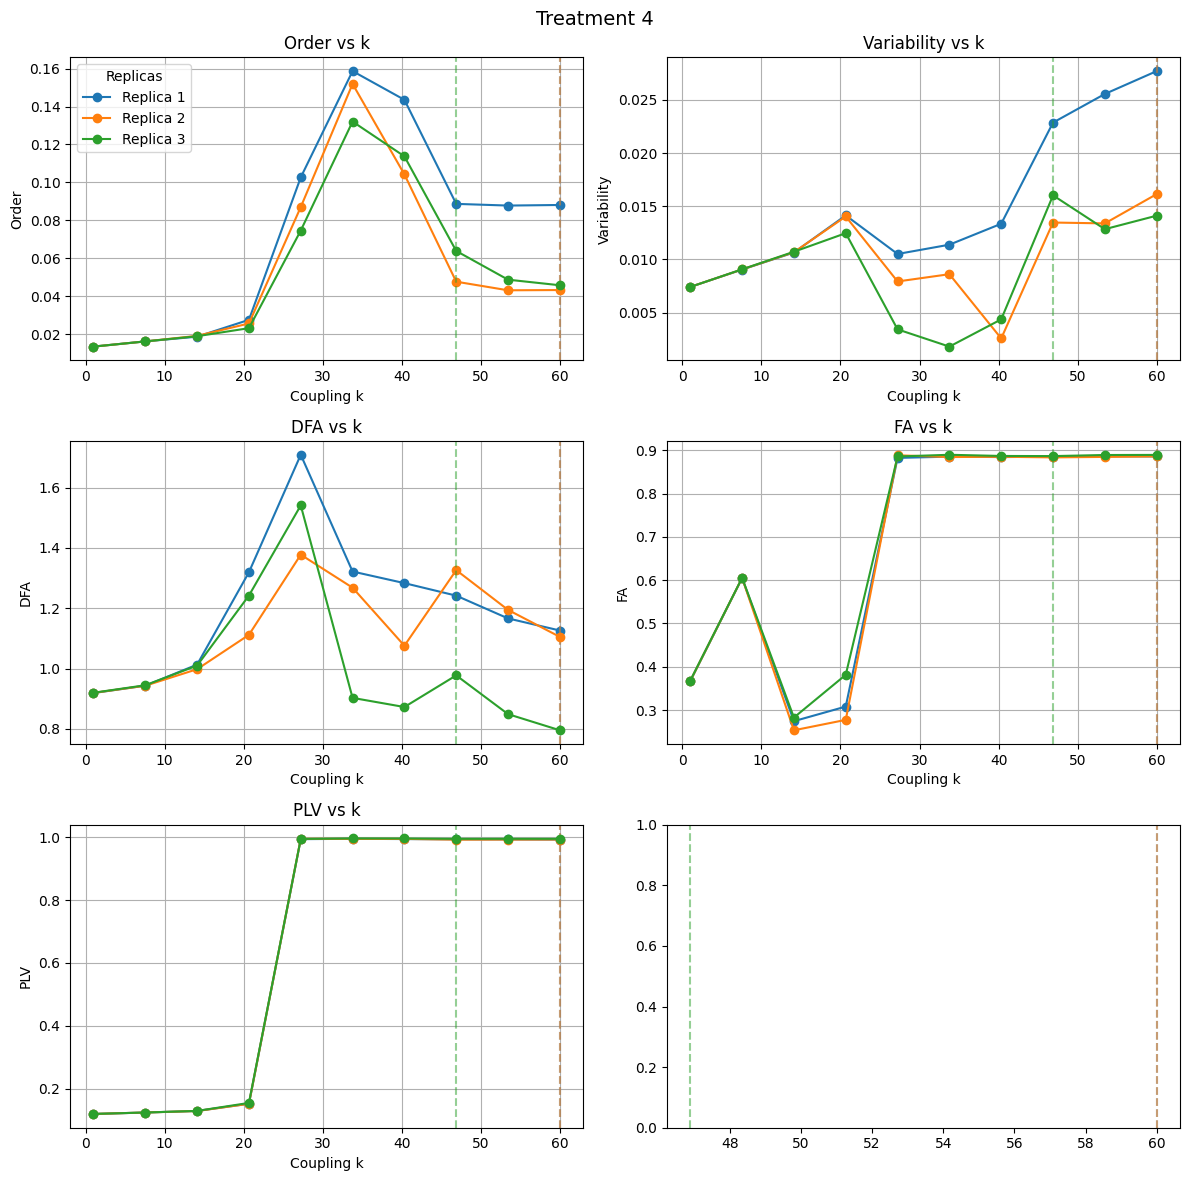

Treatment #: 5
  Replica 0: Max variability at k = 33.78
  Replica 1: Max variability at k = 20.67
  Replica 2: Max variability at k = 33.78


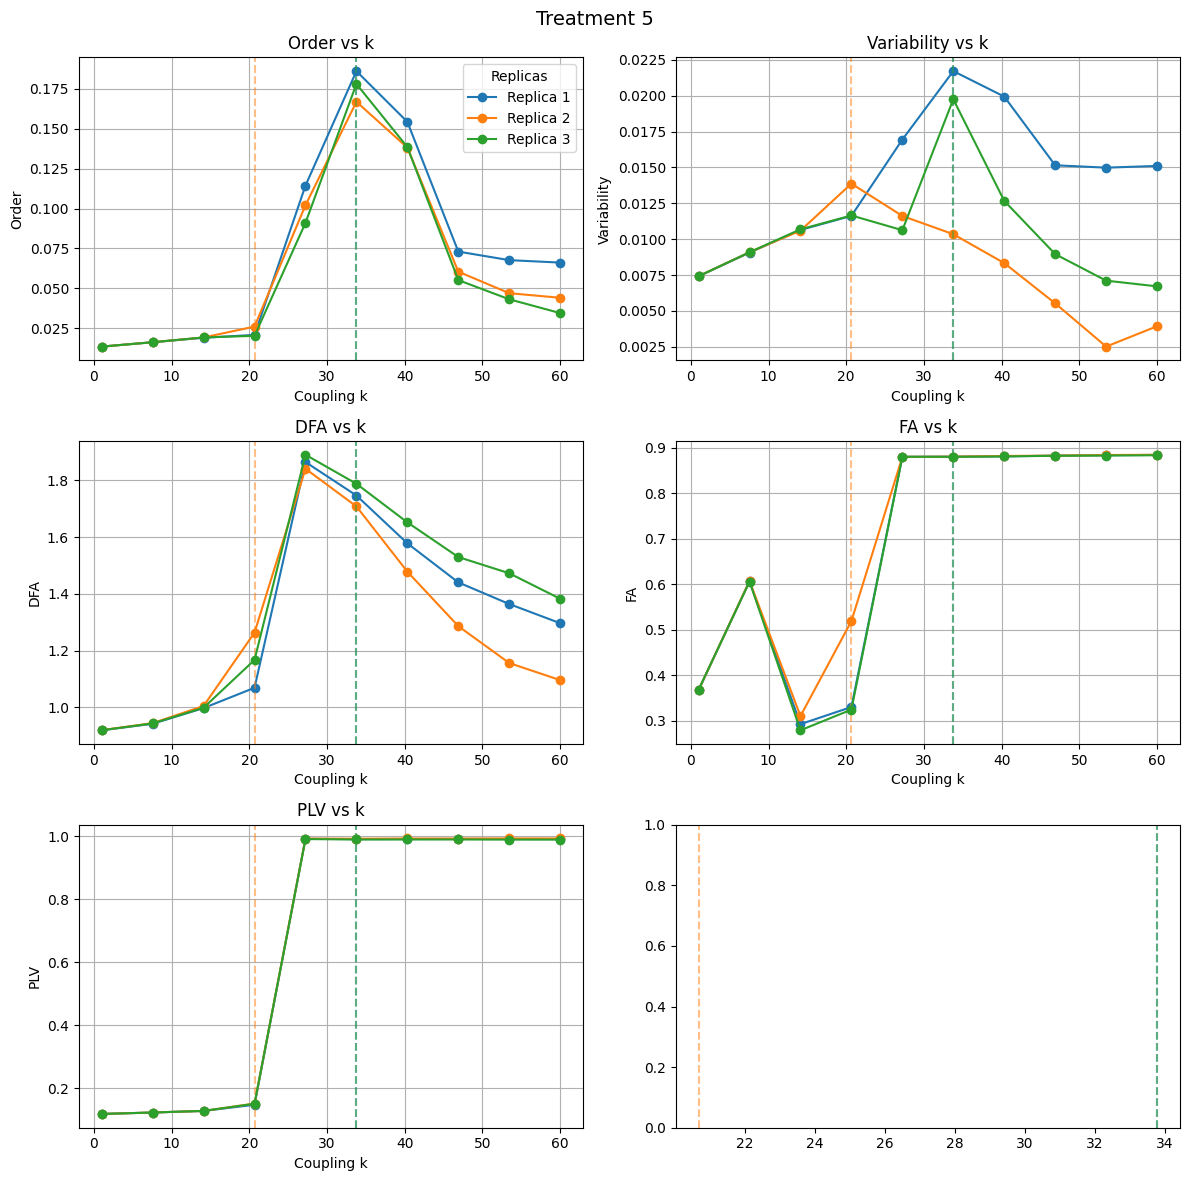

In [47]:
import matplotlib.pyplot as plt

for i in range(len(all_adj)):
    print(f"Treatment #: {i}")
    fig, axs = plt.subplots(3, 2, figsize=(12, 12))
    axs = axs.ravel()
    
    metric_names = ["Order", "Variability", "DFA", "FA", "PLV"]
    metric_data = [
        order_matrix[i, :, :],
        variability_matrix[i, :, :],
        dfa_matrix[i, :, :],
        fa_matrix[i, :, :],
        plv_matrix[i, :, :],
    ]
    
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    
    for r in range(3):
        order_results       = order_matrix[i, r, :]
        variability_results = variability_matrix[i, r, :]
        dfa_values          = dfa_matrix[i, r, :]
        fa_values           = fa_matrix[i, r, :]
        plv_results         = plv_matrix[i, r, :]
        
        # Determine k where variability is maximal
        idx_max = np.argmax(variability_results)
        k_max_var = k_values[idx_max]
        print(f"  Replica {r}: Max variability at k = {k_max_var:.2f}")
        
        # Plot all metrics
        axs[0].plot(k_values, order_results, marker='o', color=colors[r], label=f"Replica {r+1}")
        axs[1].plot(k_values, variability_results, marker='o', color=colors[r])
        axs[2].plot(k_values, dfa_values, marker='o', color=colors[r])
        axs[3].plot(k_values, fa_values, marker='o', color=colors[r])
        axs[4].plot(k_values, plv_results, marker='o', color=colors[r])
        
        # Add red vertical line for max variability
        for ax in axs:
            ax.axvline(k_max_var, color=colors[r], linestyle='--', alpha=0.5)
    
    # Titles and grid
    for ax, name in zip(axs, metric_names):
        ax.set_title(f"{name} vs k")
        ax.set_xlabel("Coupling k")
        ax.set_ylabel(name)
        ax.grid(True)
    
    axs[0].legend(title="Replicas")
    fig.suptitle(f"Treatment {i}", fontsize=14)
    plt.tight_layout()
    plt.show()


## GRAPH 1, separate treatments

Treatment #: 0 — Low mean, Low variance
  Replica 0: Max variability at k = 33.78
  Replica 1: Max variability at k = 33.78
  Replica 2: Max variability at k = 40.33


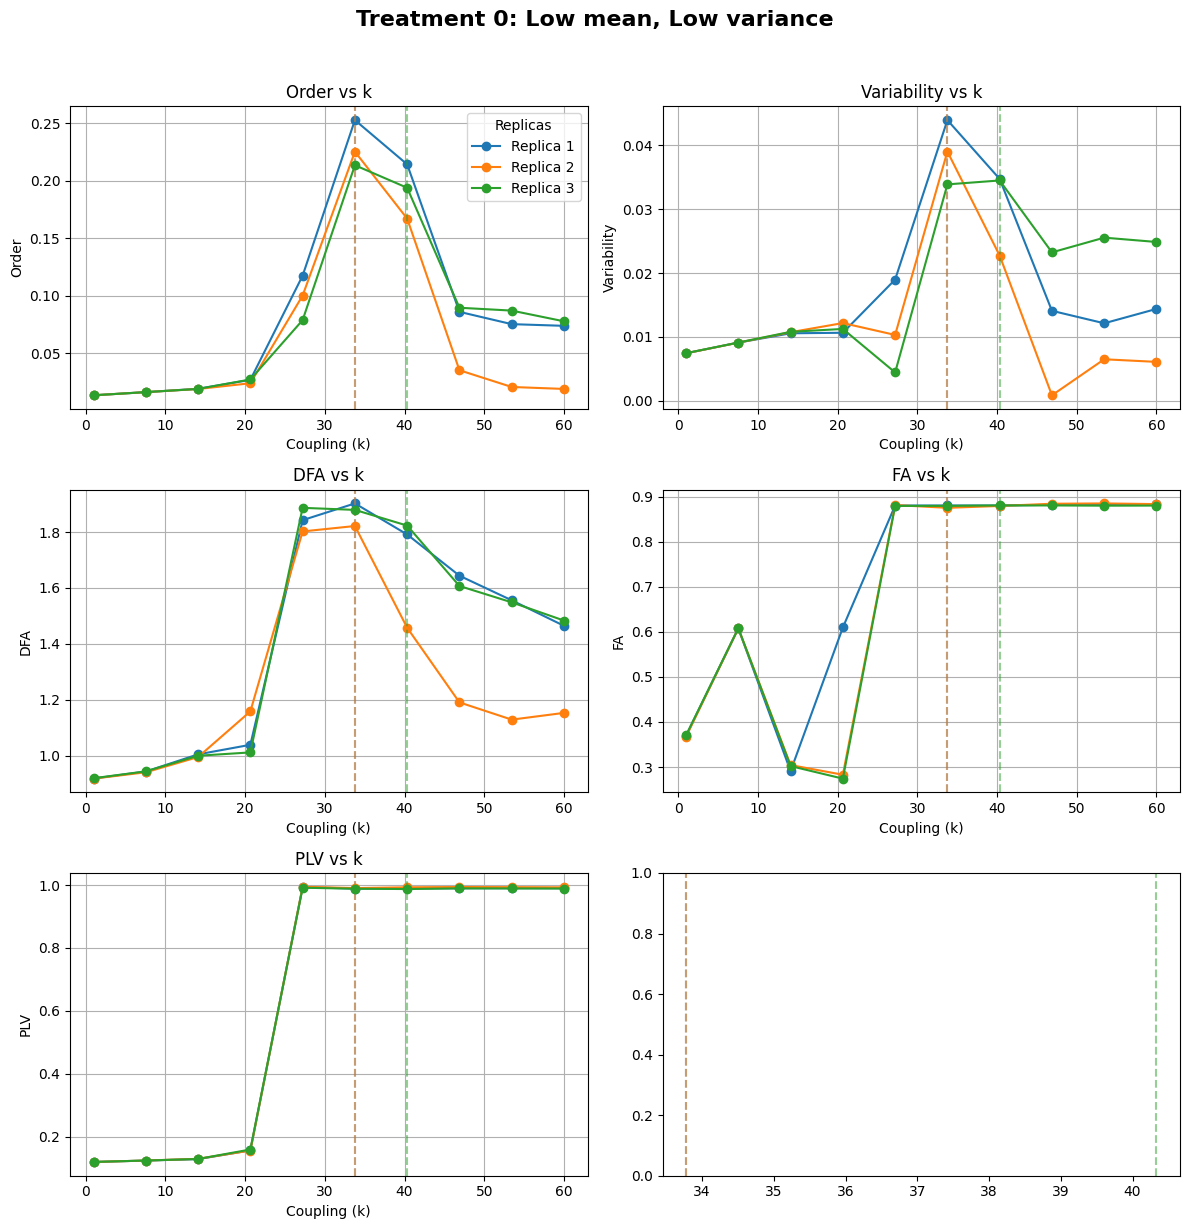

Treatment #: 1 — Low mean, High variance
  Replica 0: Max variability at k = 60.00
  Replica 1: Max variability at k = 46.89
  Replica 2: Max variability at k = 40.33


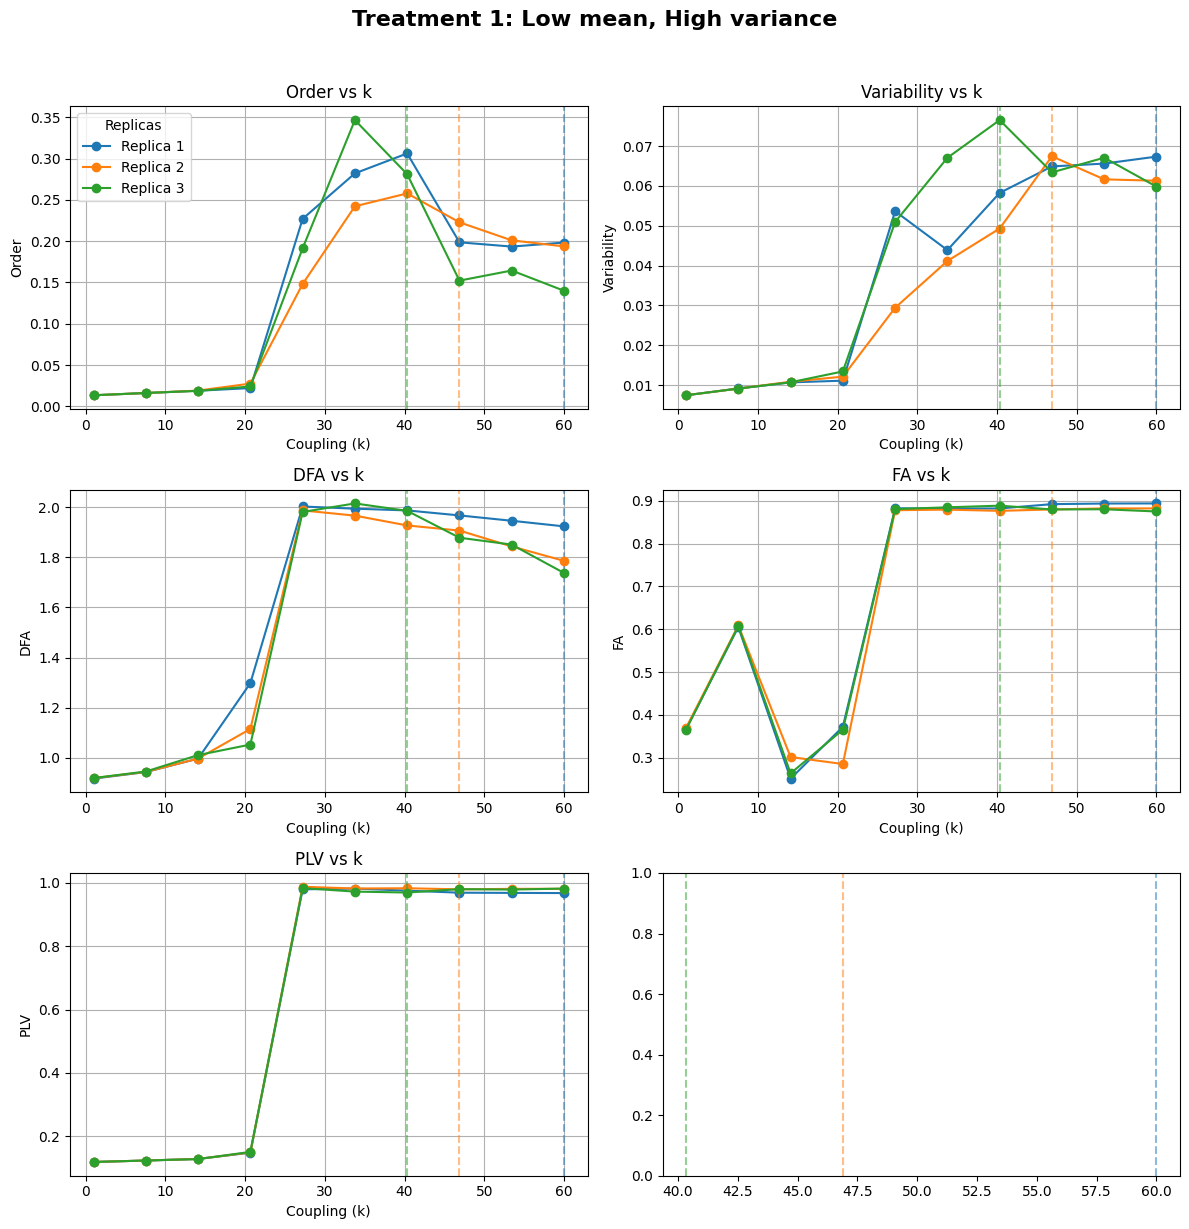

Treatment #: 2 — High mean, Low variance
  Replica 0: Max variability at k = 46.89
  Replica 1: Max variability at k = 46.89
  Replica 2: Max variability at k = 60.00


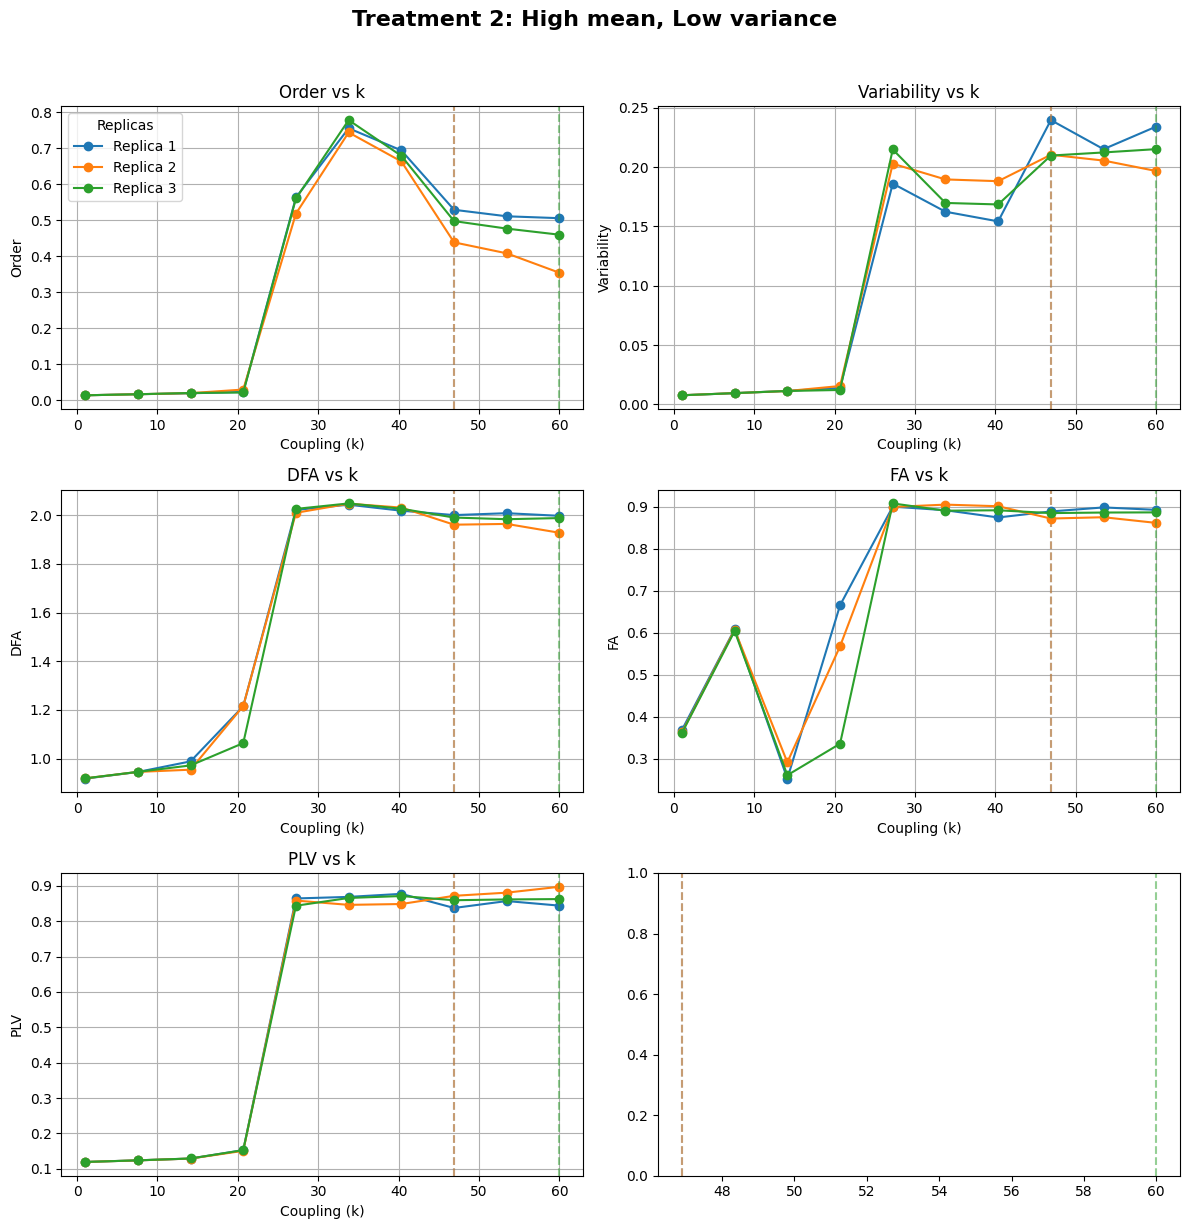

Treatment #: 3 — High mean, High variance
  Replica 0: Max variability at k = 60.00
  Replica 1: Max variability at k = 46.89
  Replica 2: Max variability at k = 60.00


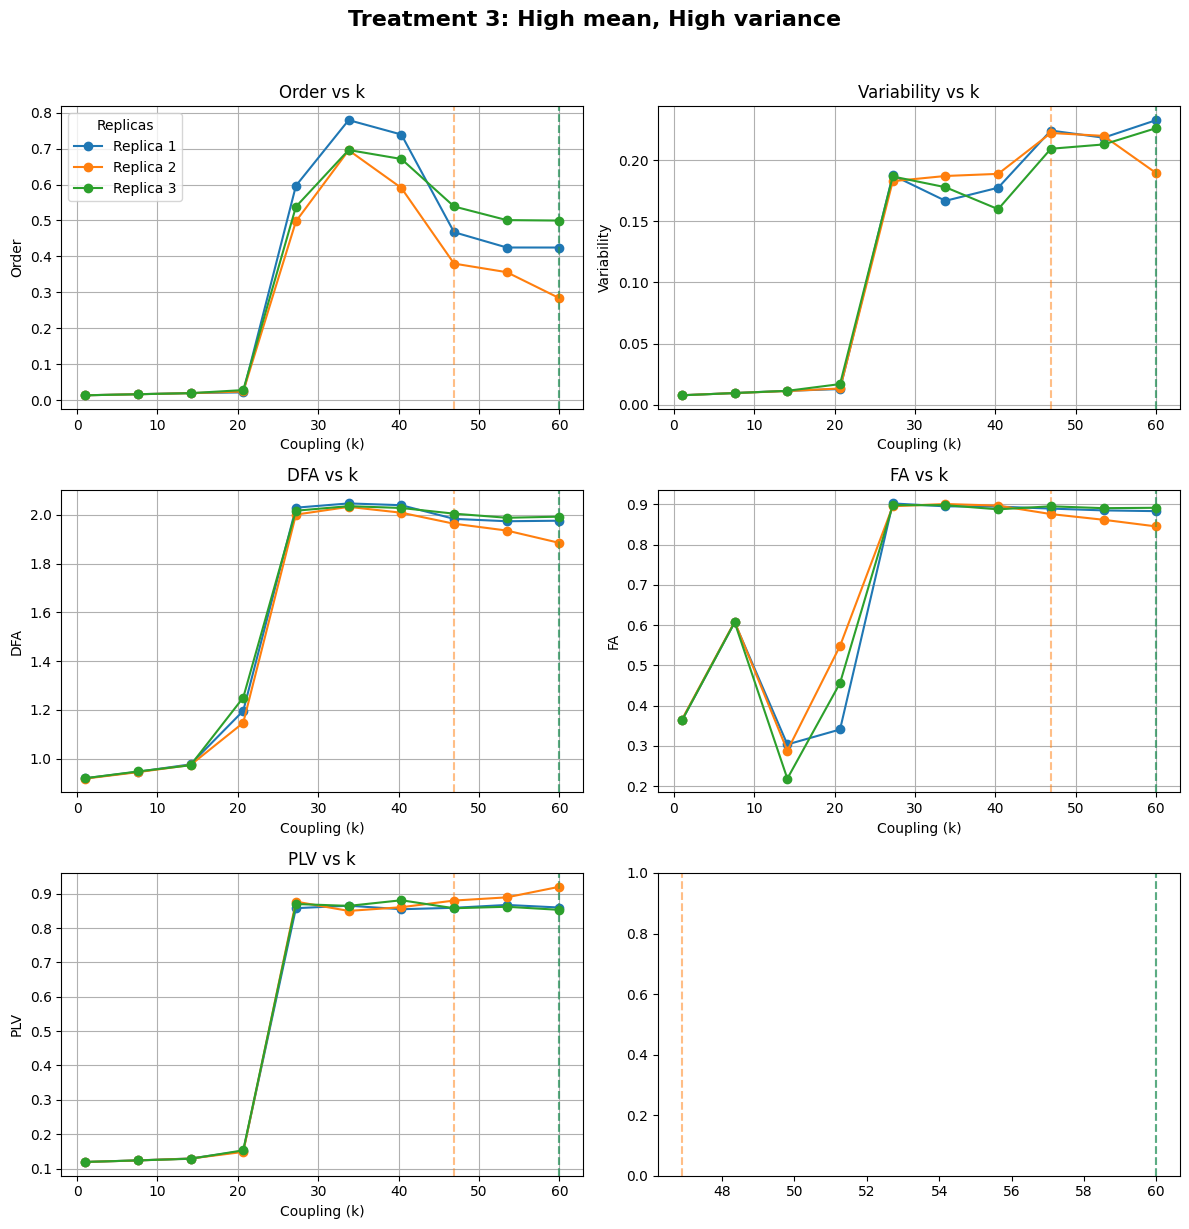

Treatment #: 4 — WS
  Replica 0: Max variability at k = 60.00
  Replica 1: Max variability at k = 60.00
  Replica 2: Max variability at k = 46.89


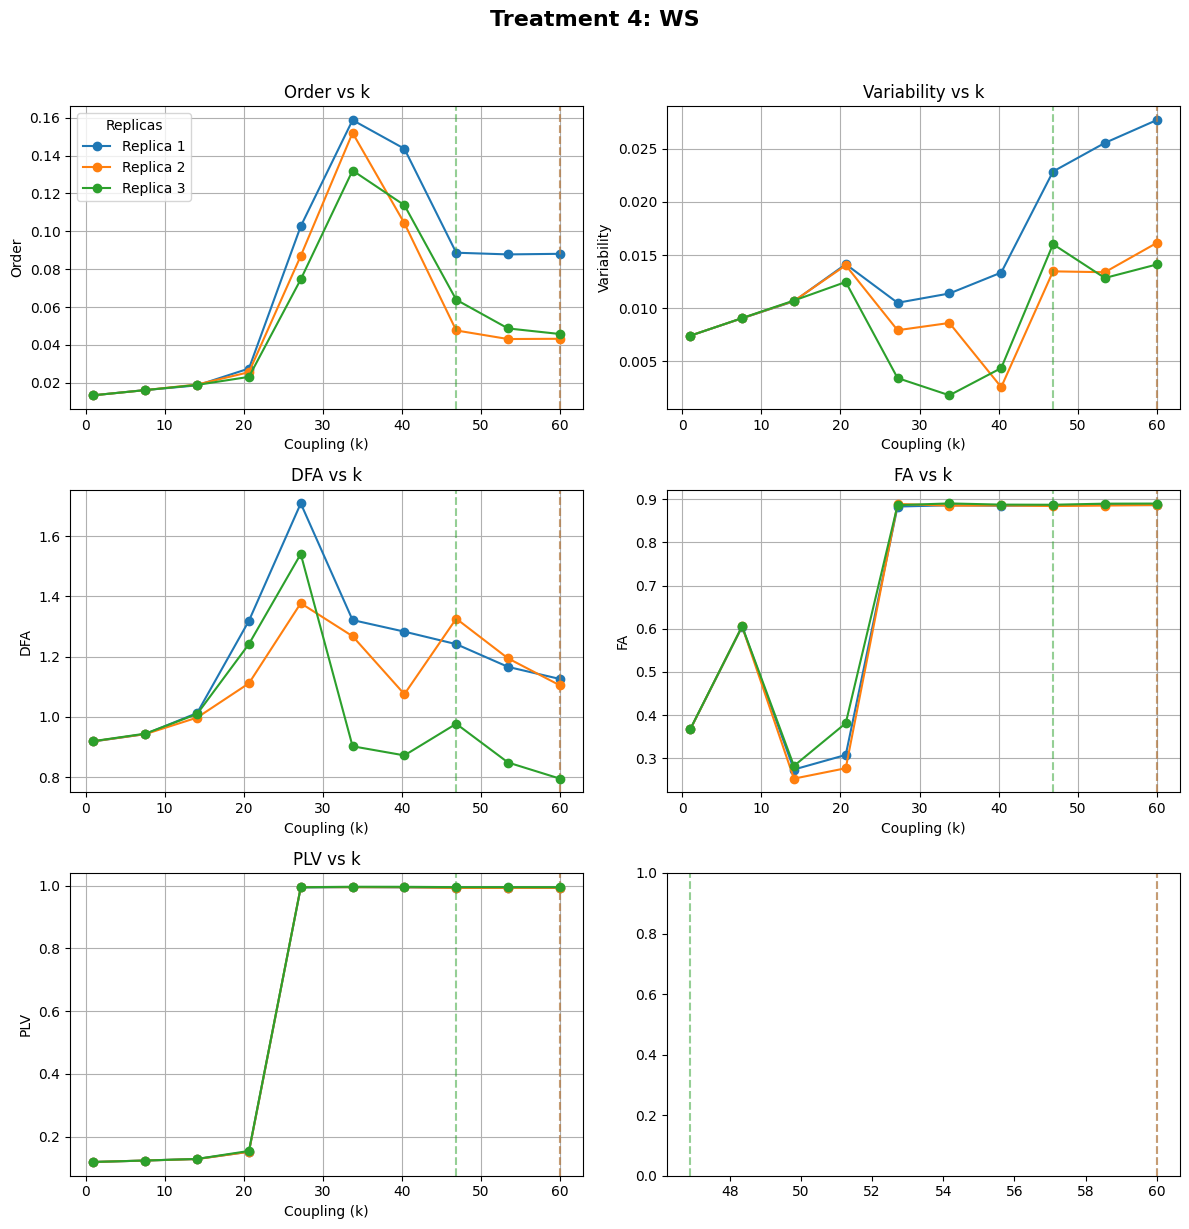

Treatment #: 5 — Erdos-Renyi
  Replica 0: Max variability at k = 33.78
  Replica 1: Max variability at k = 20.67
  Replica 2: Max variability at k = 33.78


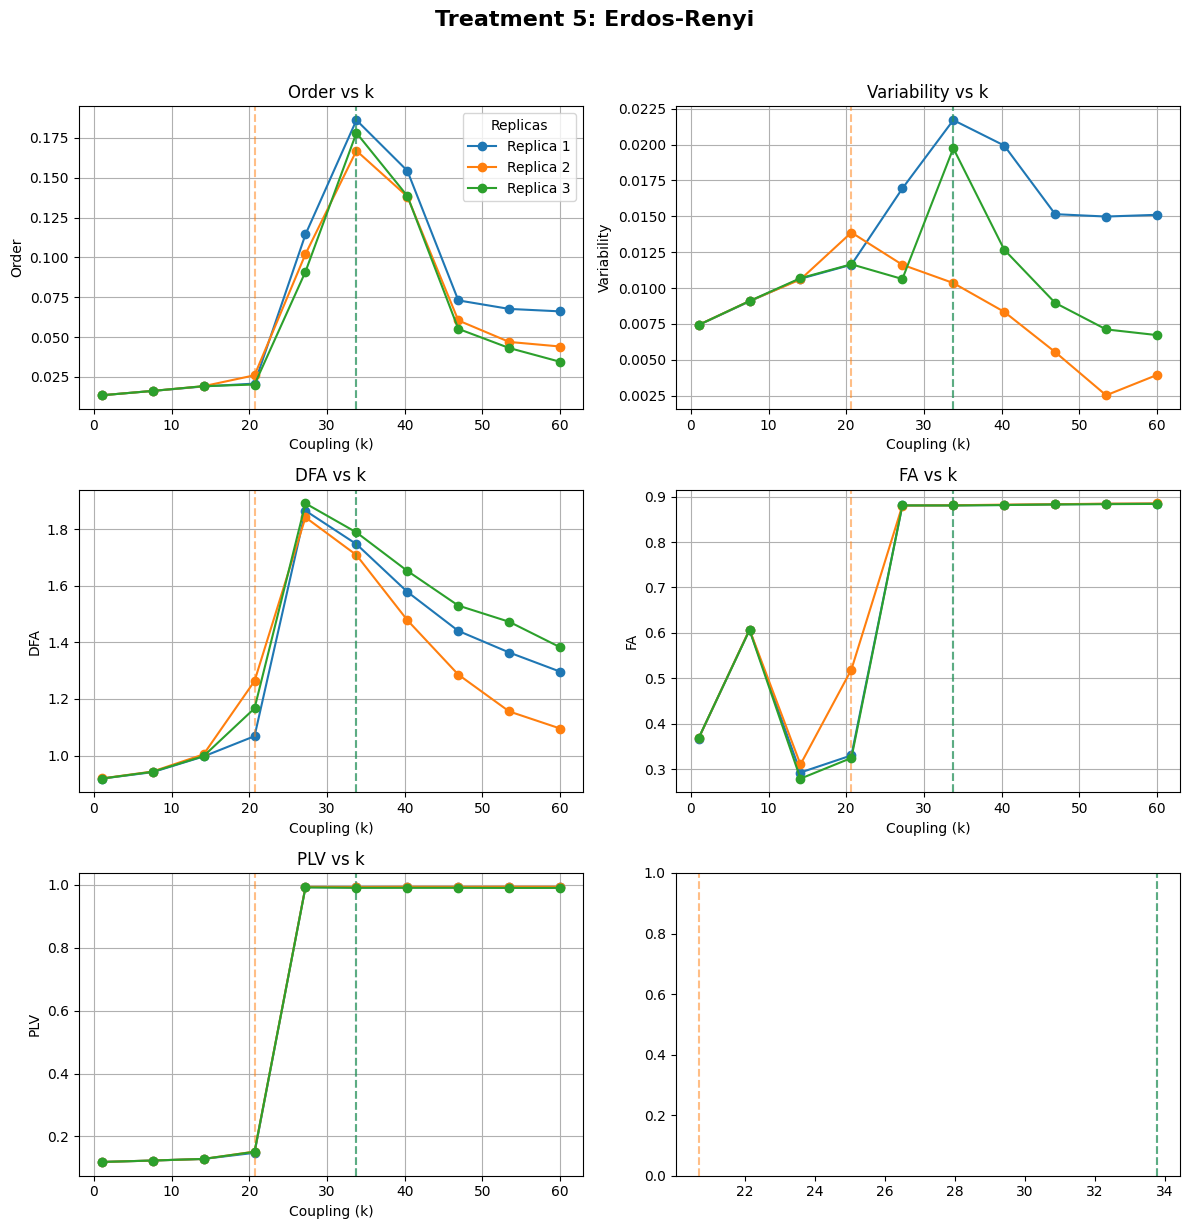

In [49]:
import matplotlib.pyplot as plt

# Define treatment names in the correct order
treatment_names = [
    "Low mean, Low variance",
    "Low mean, High variance",
    "High mean, Low variance",
    "High mean, High variance",
    "WS",
    "Erdos-Renyi"
]

for i in range(len(all_adj)):
    print(f"Treatment #: {i} — {treatment_names[i]}")
    fig, axs = plt.subplots(3, 2, figsize=(12, 12))
    axs = axs.ravel()
    
    metric_names = ["Order", "Variability", "DFA", "FA", "PLV"]
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    
    for r in range(3):
        # Extract results
        order_results       = order_matrix[i, r, :]
        variability_results = variability_matrix[i, r, :]
        dfa_values          = dfa_matrix[i, r, :]
        fa_values           = fa_matrix[i, r, :]
        plv_results         = plv_matrix[i, r, :]
        
        # Determine k where variability is maximal
        idx_max = np.argmax(variability_results)
        k_max_var = k_values[idx_max]
        print(f"  Replica {r}: Max variability at k = {k_max_var:.2f}")
        
        # Plot each metric
        axs[0].plot(k_values, order_results, marker='o', color=colors[r], label=f"Replica {r+1}")
        axs[1].plot(k_values, variability_results, marker='o', color=colors[r])
        axs[2].plot(k_values, dfa_values, marker='o', color=colors[r])
        axs[3].plot(k_values, fa_values, marker='o', color=colors[r])
        axs[4].plot(k_values, plv_results, marker='o', color=colors[r])
        
        # Add vertical line for max variability
        for ax in axs:
            ax.axvline(k_max_var, color=colors[r], linestyle='--', alpha=0.5)
    
    # Titles and axes formatting
    for ax, name in zip(axs, metric_names):
        ax.set_title(f"{name} vs k")
        ax.set_xlabel("Coupling (k)")
        ax.set_ylabel(name)
        ax.grid(True)
    
    # Legend and main figure title
    axs[0].legend(title="Replicas")
    fig.suptitle(f"Treatment {i}: {treatment_names[i]}", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


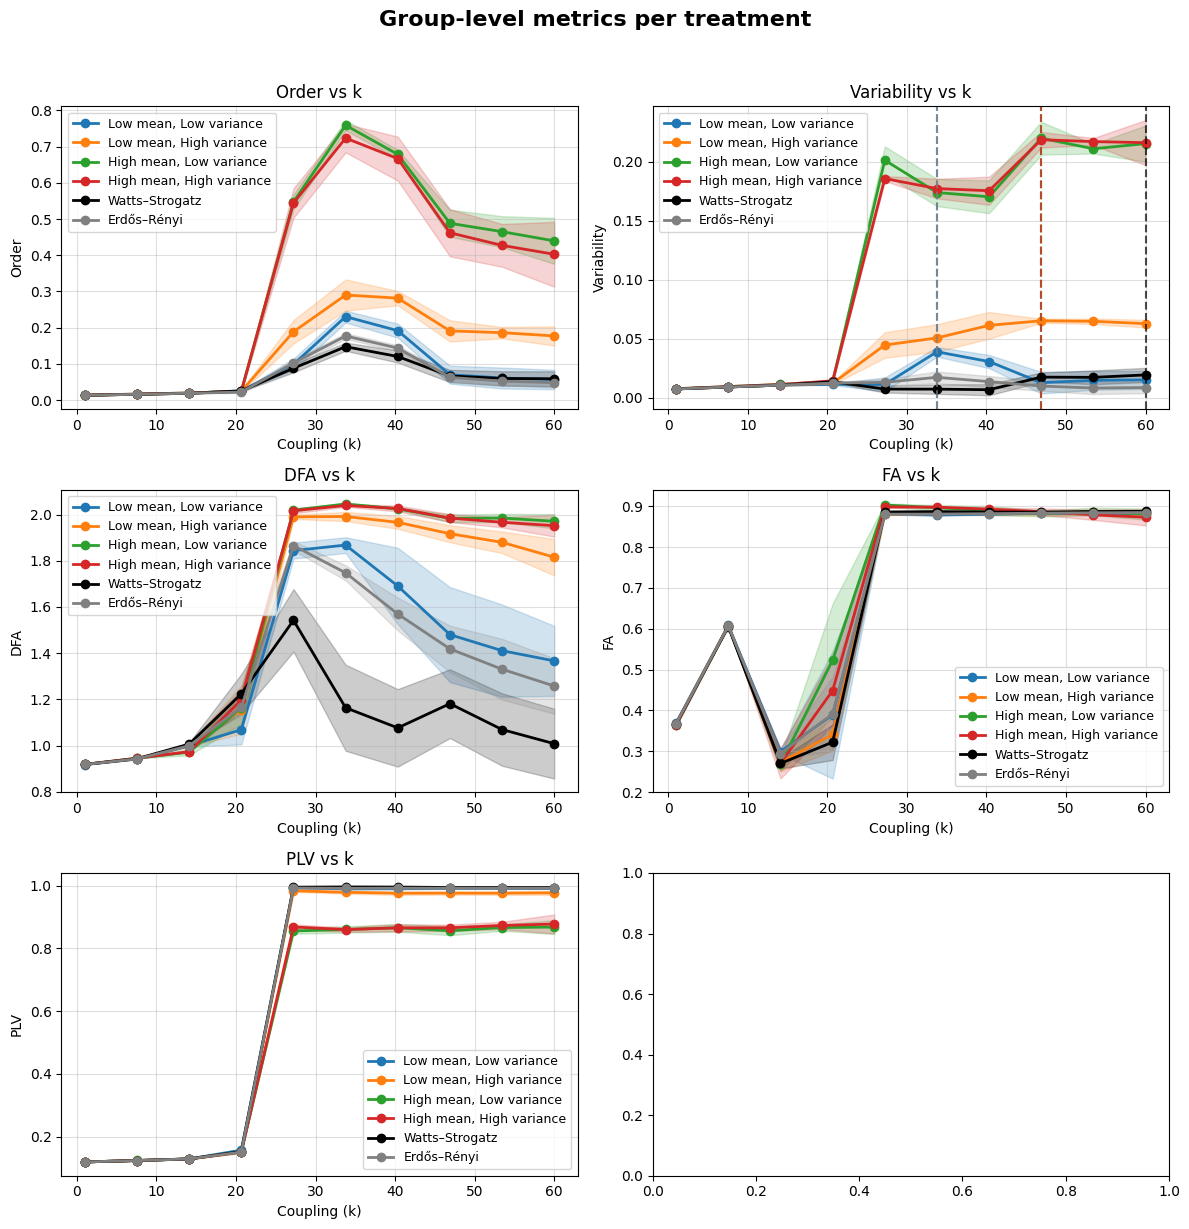

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Define names
var_names = ["Order", "Variability", "DFA", "FA", "PLV"]
matrices = [order_matrix, variability_matrix, dfa_matrix, fa_matrix, plv_matrix]
treatment_names = [
    "Low mean, Low variance",
    "Low mean, High variance",
    "High mean, Low variance",
    "High mean, High variance",
    "Watts–Strogatz",
    "Erdős–Rényi"
]

# Colors for each treatment
colors = [
    'tab:blue',     # 0
    'tab:orange',   # 1
    'tab:green',    # 2
    'tab:red',      # 3
    'black',        # 4  ← WS
    'gray'          # 5  ← ER
]

# Plot setup
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
axs = axs.ravel()

for ax, name, mat in zip(axs, var_names, matrices):
    for i in range(mat.shape[0]):  # loop over 6 treatments
        mean_vals = mat[i].mean(axis=0)     # mean across replicas (axis=1 if needed)
        std_vals  = mat[i].std(axis=0)
        
        ax.plot(
            k_values, mean_vals, marker='o',
            color=colors[i], label=treatment_names[i],
            linewidth=2, markersize=6
        )
        ax.fill_between(
            k_values, mean_vals - std_vals, mean_vals + std_vals,
            color=colors[i], alpha=0.2
        )
        
        # Highlight max variability (red dashed line)
        if name == "Variability":
            idx_max = np.argmax(mean_vals)
            k_max_var = k_values[idx_max]
            ax.axvline(k_max_var, color=colors[i], linestyle='--', alpha=0.7)
    
    ax.set_title(f"{name} vs k", fontsize=12)
    ax.set_xlabel("Coupling (k)")
    ax.set_ylabel(name)
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=9)

plt.suptitle("Group-level metrics per treatment", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



In [ ]:
import time
t0 = time.perf_counter()
# one treatment, one replica, one k — your full inner body
elapsed = time.perf_counter() - t0
print(f"One run: {elapsed/60:.2f} min")
print(f"Estimated total: {elapsed * 11 * 3 * 15 / 3600:.1f} hours")

In [ ]:
print("CUDA:", torch.cuda.is_available())
print("phase_data.shape:", phase_data.shape)  # expect (1000, 2001) or close